# Projeto 9 — Tipologias de Consumo e Acesso à Internet no Brasil
## FACOM32701 – Ciência de Dados II | Universidade Federal de Uberlândia

---

#### **Integrantes**: Arthur Rodrigues Cândido, Lucas Mendes Lacerda, Yuri Ferreira Machado

---

**Fonte de dados:** PNAD Contínua TIC 2024 — 4º Trimestre (IBGE)  
**Objetivo:** Investigar padrões estruturais relacionados à qualidade da conexão (banda larga fixa vs. móvel), finalidade do uso (trabalho vs. consumo) e exclusão digital urbana e rural, por meio de técnicas de aprendizado não supervisionado.

---

### Questões de pesquisa
1. A renda determina a qualidade da conexão (fibra/cabo vs. rede móvel pré-pago), e não apenas o acesso?
2. Existem perfis de uso voltados à geração de renda (trabalho digital)?
3. A exclusão digital persiste em periferias urbanas, e não apenas em áreas rurais?
4. Quais são as diferenças entre usuários urbanos e rurais?

---

### Pipeline do projeto
1. Coleta e leitura dos microdados (arquivo de largura fixa)
2. Pré-processamento e engenharia de variáveis
3. Análise Exploratória (EDA)
4. Redução de dimensionalidade (PCA, t-SNE)
5. Clusterização (K-Means, Hierárquico, DBSCAN)
6. Avaliação e interpretação dos clusters


## 1. Importações e Configurações

In [2]:
# Importações e configurações gerais
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score,
                              normalized_mutual_info_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Bibliotecas importadas com sucesso!")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
import sklearn; print(f"scikit-learn: {sklearn.__version__}")


Bibliotecas importadas com sucesso!
pandas: 3.0.1
numpy: 2.4.2
scikit-learn: 1.8.0


## 2. Coleta de Dados

Os microdados da PNAD Contínua TIC 2024 (4º Trimestre) são disponibilizados pelo IBGE em formato de largura fixa (`.txt`). O dicionário de variáveis (`.xls`) define a posição inicial e o tamanho de cada campo.

**Fonte:** https://ftp.ibge.gov.br/Trabalho_e_Rendimento/Pesquisa_Nacional_por_Amostra_de_Domicilios_continua/Anual/Microdados/Trimestre/Trimestre_4/

### Layout das variáveis selecionadas

| Código | Posição | Tamanho | Descrição |
|--------|---------|---------|-----------|
| UF | 6 | 2 | Unidade da Federação |
| V1022 | 33 | 1 | Situação do domicílio (1=Urbana, 2=Rural) |
| V2007 | 95 | 1 | Sexo (1=Homem, 2=Mulher) |
| V2009 | 104 | 3 | Idade |
| V2010 | 107 | 1 | Cor ou raça |
| VD3004 | 1116 | 1 | Nível de instrução |
| VD4002 | 1121 | 1 | Condição de ocupação |
| VD4020 | 1162 | 8 | Rendimento mensal efetivo |
| S01029 | 493 | 1 | Acesso à internet no domicílio |
| S01030A1 | 502 | 1 | Conexão domiciliar: rede móvel 3G/4G/5G |
| S01030A3 | 504 | 1 | Conexão domiciliar: banda larga fixa |
| S07001 | 508 | 1 | Utilizou internet nos últimos 3 meses |
| S070021–S070025 | 510–514 | 1 | Equipamentos utilizados |
| S070041–S0700412 | 518–529 | 1 | Finalidades do uso da internet 

In [3]:
# Layout das variáveis (posições 0-based para Python)
LAYOUT = {
    'Ano':        (0,   4),
    'Trimestre':  (4,   1),
    'UF':         (5,   2),
    'V1022':      (32,  1),   # Situação do domicílio
    # Características do morador
    'V2007':      (94,  1),   # Sexo
    'V2009':      (103, 3),   # Idade
    'V2010':      (106, 1),   # Cor ou raça
    # Escolaridade e ocupação
    'VD3004':     (1115, 1),  # Nível de instrução
    'VD4002':     (1120, 1),  # Condição de ocupação
    # Rendimento
    'VD4020':     (1161, 8),  # Rendimento mensal efetivo
    # Domicílio TIC
    'S01028':     (490, 1),   # Tem microcomputador
    'S01028A':    (491, 1),   # Tem tablet
    'S01029':     (492, 1),   # Tem acesso internet no domicílio
    'S01030A1':   (501, 1),   # Conexão: rede móvel 3G/4G/5G
    'S01030A2':   (502, 1),   # Conexão: discada
    'S01030A3':   (503, 1),   # Conexão: banda larga fixa
    # TIC - Acesso individual
    'S07001':     (507, 1),   # Utilizou internet
    # TIC - Equipamentos individuais
    'S070021':    (509, 1),   # Microcomputador
    'S070022':    (510, 1),   # Tablet
    'S070023':    (511, 1),   # Celular
    'S070024':    (512, 1),   # Televisão
    'S070025':    (513, 1),   # Outro
    # TIC - Finalidades
    'S070041':    (517, 1),   # E-mail
    'S070042':    (518, 1),   # Mensagens (WhatsApp etc.)
    'S070043':    (519, 1),   # Chamadas voz/vídeo
    'S070044':    (520, 1),   # Vídeos/streaming
    'S070045':    (521, 1),   # Redes sociais
    'S070046':    (522, 1),   # Músicas/rádio/podcast
    'S070047':    (523, 1),   # Leitura de notícias/livros
    'S070048':    (524, 1),   # Jogos
    'S070049':    (525, 1),   # Compras online
    'S0700410':   (526, 1),   # Venda/anúncio de bens
    'S0700411':   (527, 1),   # Serviços públicos
    'S0700412':   (528, 1),   # Banco/financeiro
    # TIC - Motivo não acesso
    'S07005':     (532, 1),
    # TIC - Celular
    'S07006':     (539, 1),
    'S07007':     (540, 1),
}

print(f"Total de variáveis no layout: {len(LAYOUT)}")


Total de variáveis no layout: 37


# Leitura dos Microdados no formato de arquivo .txt (de largura fixa)

In [4]:
colspecs = [(v[0], v[0] + v[1]) for v in LAYOUT.values()]
names = list(LAYOUT.keys())

print("Lendo microdados (arquivo ~3.3GB, pode demorar alguns minutos)...")
df_raw = pd.read_fwf(
    'PNADC_2024_trimestre4.txt',
    colspecs=colspecs,
    names=names,
    header=None,
    dtype=str,
    encoding='latin-1'
)

# Converter para numérico
for col in df_raw.columns:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"Dados lidos com sucesso!")
print(f"Shape: {df_raw.shape}")
print(f"Registros: {len(df_raw):,}")
df_raw.head(3)


Lendo microdados (arquivo ~3.3GB, pode demorar alguns minutos)...
Dados lidos com sucesso!
Shape: (469334, 37)
Registros: 469,334


,Ano,Trimestre,UF,V1022,V2007,V2009,V2010,VD3004,VD4002,VD4020,...,S070046,S070047,S070048,S070049,S0700410,S0700411,S0700412,S07005,S07006,S07007
0,2024,4,11,1,2,22,1,5.0,NaN,NaN,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,NaN,1.0,1.0
1,2024,4,11,1,1,22,4,5.0,1.0,1412.0,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,NaN,1.0,1.0
2,2024,4,11,1,2,46,4,5.0,1.0,1412.0,...,1.0,1.0,2.0,2.0,2.0,1.0,1.0,NaN,1.0,1.0


## 3. Pré-processamento

### 3.1 Tratamento de valores nulos
- Variáveis TIC: NaN indica "não se aplica" (ex.: não usou internet) → convertido para 0 nas variáveis binárias
- Rendimento: NaN para não ocupados → preenchido com 0
- Escolaridade: NaN → preenchido com a mediana

### 3.2 Engenharia de variáveis
- Variáveis binárias (1=Sim, 0=Não) para todos os itens TIC
- Variáveis de contexto socioeconômico: urbano, ocupado, rendimento, escolaridade, idade

### 3.3 Filtragem
- Apenas pessoas com 10 anos ou mais de idade
- Apenas registros com resposta à pergunta de internet (S07001)


In [5]:
# Mapeamentos geográficos
uf_regiao = {
    11:'Norte', 12:'Norte', 13:'Norte', 14:'Norte', 15:'Norte', 16:'Norte', 17:'Norte',
    21:'Nordeste', 22:'Nordeste', 23:'Nordeste', 24:'Nordeste', 25:'Nordeste',
    26:'Nordeste', 27:'Nordeste', 28:'Nordeste', 29:'Nordeste',
    31:'Sudeste', 32:'Sudeste', 33:'Sudeste', 35:'Sudeste',
    41:'Sul', 42:'Sul', 43:'Sul',
    50:'Centro-Oeste', 51:'Centro-Oeste', 52:'Centro-Oeste', 53:'Centro-Oeste'
}
uf_nome = {
    11:'RO', 12:'AC', 13:'AM', 14:'RR', 15:'PA', 16:'AP', 17:'TO',
    21:'MA', 22:'PI', 23:'CE', 24:'RN', 25:'PB', 26:'PE', 27:'AL', 28:'SE', 29:'BA',
    31:'MG', 32:'ES', 33:'RJ', 35:'SP',
    41:'PR', 42:'SC', 43:'RS',
    50:'MS', 51:'MT', 52:'GO', 53:'DF'
}

df_raw['regiao'] = df_raw['UF'].map(uf_regiao)
df_raw['uf_nome'] = df_raw['UF'].map(uf_nome)
df_raw['situacao_domicilio'] = df_raw['V1022'].map({1:'Urbana', 2:'Rural'})
df_raw['sexo'] = df_raw['V2007'].map({1:'Homem', 2:'Mulher'})

esc_map = {1:'Sem instrucao', 2:'Fund. incompleto', 3:'Fund. completo',
           4:'Medio incompleto', 5:'Medio completo', 6:'Superior incompleto', 7:'Superior completo'}
df_raw['escolaridade'] = df_raw['VD3004'].map(esc_map)

# Filtrar >= 10 anos e com resposta à pergunta de internet
df = df_raw[(df_raw['V2009'] >= 10) & (df_raw['S07001'].notna())].copy()
print(f"Registros após filtro (>=10 anos, S07001 preenchido): {len(df):,}")


Registros após filtro (>=10 anos, S07001 preenchido): 411,761


In [6]:
# Criação de variáveis binárias
def to_bin(col, df):
    """Converte 1=Sim, 2=Não para 1/0. NaN → 0 (não se aplica)."""
    return (df[col] == 1).astype(float)

# Acesso à internet
df['b_internet'] = to_bin('S07001', df)

# Equipamentos individuais
df['b_equip_pc'] = to_bin('S070021', df)
df['b_equip_tablet'] = to_bin('S070022', df)
df['b_equip_celular'] = to_bin('S070023', df)
df['b_equip_tv'] = to_bin('S070024', df)
df['b_equip_outro'] = to_bin('S070025', df)

# Conexão domiciliar
df['b_dom_rede_movel'] = to_bin('S01030A1', df)
df['b_dom_bl_fixa'] = to_bin('S01030A3', df)
df['b_dom_internet'] = to_bin('S01029', df)

# Finalidades
df['b_fin_email'] = to_bin('S070041', df)
df['b_fin_mensagens'] = to_bin('S070042', df)
df['b_fin_chamadas'] = to_bin('S070043', df)
df['b_fin_streaming'] = to_bin('S070044', df)
df['b_fin_redes_sociais'] = to_bin('S070045', df)
df['b_fin_musica'] = to_bin('S070046', df)
df['b_fin_noticias'] = to_bin('S070047', df)
df['b_fin_jogos'] = to_bin('S070048', df)
df['b_fin_compras'] = to_bin('S070049', df)
df['b_fin_venda'] = to_bin('S0700410', df)
df['b_fin_serv_pub'] = to_bin('S0700411', df)
df['b_fin_banco'] = to_bin('S0700412', df)

# Contexto socioeconômico
df['urbano'] = (df['V1022'] == 1).astype(float)
df['ocupado'] = (df['VD4002'] == 1).astype(float)
df['rendimento'] = df['VD4020'].fillna(0)
df['escolaridade_num'] = df['VD3004'].fillna(df['VD3004'].median())
df['idade'] = df['V2009']
df['sexo_num'] = (df['V2007'] == 1).astype(float)

# Faixa etária
df['faixa_etaria'] = pd.cut(df['idade'],
                             bins=[10, 17, 24, 34, 44, 54, 64, 100],
                             labels=['10-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+'])

print(f"Variáveis binárias criadas: {len([c for c in df.columns if c.startswith('b_')])}")
print(f"Shape final: {df.shape}")


Variáveis binárias criadas: 21
Shape final: (411761, 70)


In [7]:
# Verificação de valores nulos
print("=== Análise de Valores Nulos ===")
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print("\nTop 10 variáveis com mais nulos:")
print(null_pct.head(10).to_string())

print("\n=== Estatísticas Descritivas Principais ===")
desc_cols = ['idade', 'rendimento', 'escolaridade_num', 'b_internet', 'urbano', 'ocupado']
print(df[desc_cols].describe().round(2).to_string())


=== Análise de Valores Nulos ===

Top 10 variáveis com mais nulos:
S07005      100.000000
VD4020       50.375582
VD4002       45.976671
S07007       13.940611
S070023      13.142333
S070022      13.142333
S0700412     13.142333
S070047      13.142333
S070049      13.142333
S0700410     13.142333

=== Estatísticas Descritivas Principais ===
           idade  rendimento  escolaridade_num  b_internet     urbano    ocupado
count  411761.00   411761.00         411761.00   411761.00  411761.00  411761.00
mean       42.12     1543.68              3.85        0.87       0.73       0.51
std        19.83     3648.20              1.90        0.34       0.44       0.50
min        10.00        0.00              1.00        0.00       0.00       0.00
25%        25.00        0.00              2.00        1.00       0.00       0.00
50%        41.00        0.00              4.00        1.00       1.00       1.00
75%        57.00     2000.00              5.00        1.00       1.00       1.00
max       

## 4. Análise Exploratória de Dados (EDA)

### 4.1 Estatísticas Descritivas


In [8]:
# Estatísticas descritivas gerais
n_total = len(df)
n_internet = df['b_internet'].sum()
n_urbano = df['urbano'].sum()
n_ocupado = df['ocupado'].sum()

print("=" * 60)
print("ESTATÍSTICAS DESCRITIVAS - PNAD Contínua TIC 2024 (4T)")
print("=" * 60)
print(f"Total de entrevistados (>=10 anos): {n_total:,}")
print(f"Usuários de internet: {n_internet:,.0f} ({n_internet/n_total*100:.1f}%)")
print(f"Não usuários: {n_total - n_internet:,.0f} ({(1-n_internet/n_total)*100:.1f}%)")
print(f"Domicílios urbanos: {n_urbano:,.0f} ({n_urbano/n_total*100:.1f}%)")
print(f"Ocupados: {n_ocupado:,.0f} ({n_ocupado/n_total*100:.1f}%)")
print(f"Idade média: {df['idade'].mean():.1f} anos (mediana: {df['idade'].median():.0f})")
print(f"Rendimento médio (trabalhadores): R$ {df[df['rendimento']>0]['rendimento'].mean():,.2f}")

print("\n--- Acesso à internet por situação ---")
print(df.groupby('situacao_domicilio')['b_internet'].mean().mul(100).round(1))

print("\n--- Acesso por região ---")
print(df.groupby('regiao')['b_internet'].mean().mul(100).round(1))

print("\n--- Conexão domiciliar ---")
print(f"Banda Larga Fixa: {df['b_dom_bl_fixa'].mean()*100:.1f}%")
print(f"Rede Móvel (3G/4G/5G): {df['b_dom_rede_movel'].mean()*100:.1f}%")


ESTATÍSTICAS DESCRITIVAS - PNAD Contínua TIC 2024 (4T)
Total de entrevistados (>=10 anos): 411,761
Usuários de internet: 357,646 (86.9%)
Não usuários: 54,115 (13.1%)
Domicílios urbanos: 302,060 (73.4%)
Ocupados: 209,311 (50.8%)
Idade média: 42.1 anos (mediana: 41)
Rendimento médio (trabalhadores): R$ 3,187.01

--- Acesso à internet por situação ---
situacao_domicilio
Rural     79.5
Urbana    89.5
Name: b_internet, dtype: float64

--- Acesso por região ---
regiao
Centro-Oeste    91.5
Nordeste        84.0
Norte           86.0
Sudeste         87.8
Sul             89.0
Name: b_internet, dtype: float64

--- Conexão domiciliar ---
Banda Larga Fixa: 84.7%
Rede Móvel (3G/4G/5G): 73.3%


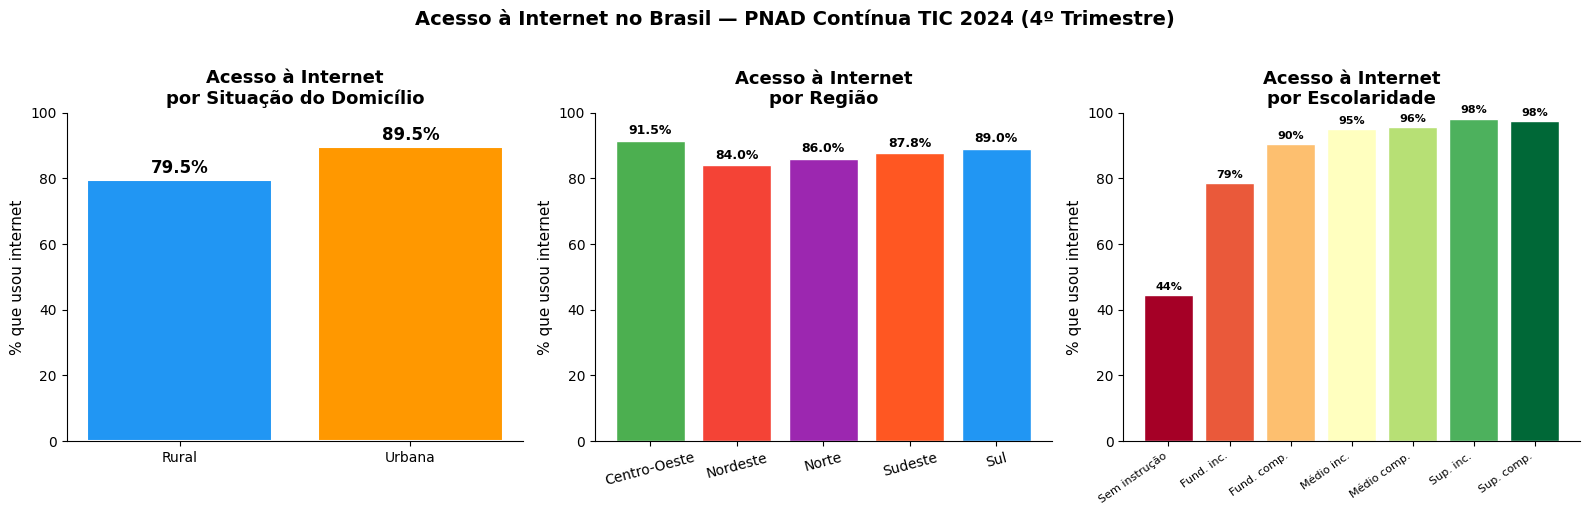

In [9]:
# Figura 1: Acesso à internet por situação, região e escolaridade
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Por situação
acesso_sit = df.groupby('situacao_domicilio')['b_internet'].mean() * 100
bars = axes[0].bar(acesso_sit.index, acesso_sit.values,
                   color=['#2196F3', '#FF9800'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Acesso à Internet\npor Situação do Domicílio', fontweight='bold')
axes[0].set_ylabel('% que usou internet'); axes[0].set_ylim(0, 100)
for bar, val in zip(bars, acesso_sit.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Por região
acesso_reg = df.groupby('regiao')['b_internet'].mean() * 100
colors_reg = ['#4CAF50', '#F44336', '#9C27B0', '#FF5722', '#2196F3']
bars2 = axes[1].bar(acesso_reg.index, acesso_reg.values, color=colors_reg, edgecolor='white')
axes[1].set_title('Acesso à Internet\npor Região', fontweight='bold')
axes[1].set_ylabel('% que usou internet'); axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, acesso_reg.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

# Por escolaridade
esc_labels = {1:'Sem instrução', 2:'Fund. inc.', 3:'Fund. comp.',
              4:'Médio inc.', 5:'Médio comp.', 6:'Sup. inc.', 7:'Sup. comp.'}
acesso_esc = df.groupby('VD3004')['b_internet'].mean() * 100
acesso_esc.index = [esc_labels.get(i, str(i)) for i in acesso_esc.index]
cmap = plt.cm.get_cmap('RdYlGn', len(acesso_esc))
bars3 = axes[2].bar(range(len(acesso_esc)), acesso_esc.values,
                    color=[cmap(i) for i in range(len(acesso_esc))], edgecolor='white')
axes[2].set_title('Acesso à Internet\npor Escolaridade', fontweight='bold')
axes[2].set_ylabel('% que usou internet'); axes[2].set_ylim(0, 100)
axes[2].set_xticks(range(len(acesso_esc)))
axes[2].set_xticklabels(acesso_esc.index, rotation=35, ha='right', fontsize=8)
for bar, val in zip(bars3, acesso_esc.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.0f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=8)
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('Acesso à Internet no Brasil — PNAD Contínua TIC 2024 (4º Trimestre)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


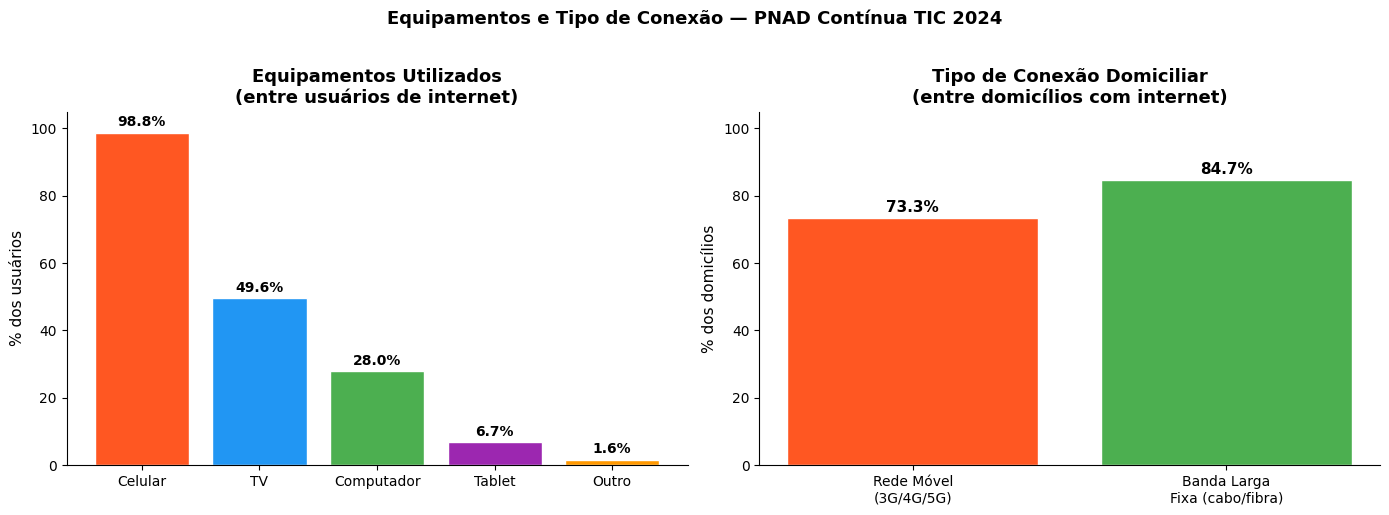

In [10]:
# Figura 2: Equipamentos e tipo de conexão
df_usr = df[df['b_internet'] == 1].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

equip = {
    'Celular': df_usr['b_equip_celular'].mean()*100,
    'Computador': df_usr['b_equip_pc'].mean()*100,
    'TV': df_usr['b_equip_tv'].mean()*100,
    'Tablet': df_usr['b_equip_tablet'].mean()*100,
    'Outro': df_usr['b_equip_outro'].mean()*100,
}
equip_s = dict(sorted(equip.items(), key=lambda x: x[1], reverse=True))
colors_eq = ['#FF5722', '#2196F3', '#4CAF50', '#9C27B0', '#FF9800']
bars_eq = axes[0].bar(equip_s.keys(), equip_s.values(), color=colors_eq, edgecolor='white')
axes[0].set_title('Equipamentos Utilizados\n(entre usuários de internet)', fontweight='bold')
axes[0].set_ylabel('% dos usuários'); axes[0].set_ylim(0, 105)
for bar, val in zip(bars_eq, equip_s.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

conexao = {
    'Rede Móvel\n(3G/4G/5G)': df['b_dom_rede_movel'].mean()*100,
    'Banda Larga\nFixa (cabo/fibra)': df['b_dom_bl_fixa'].mean()*100,
}
colors_con = ['#FF5722', '#4CAF50']
bars_con = axes[1].bar(conexao.keys(), conexao.values(), color=colors_con, edgecolor='white')
axes[1].set_title('Tipo de Conexão Domiciliar\n(entre domicílios com internet)', fontweight='bold')
axes[1].set_ylabel('% dos domicílios'); axes[1].set_ylim(0, 105)
for bar, val in zip(bars_con, conexao.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Equipamentos e Tipo de Conexão — PNAD Contínua TIC 2024',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


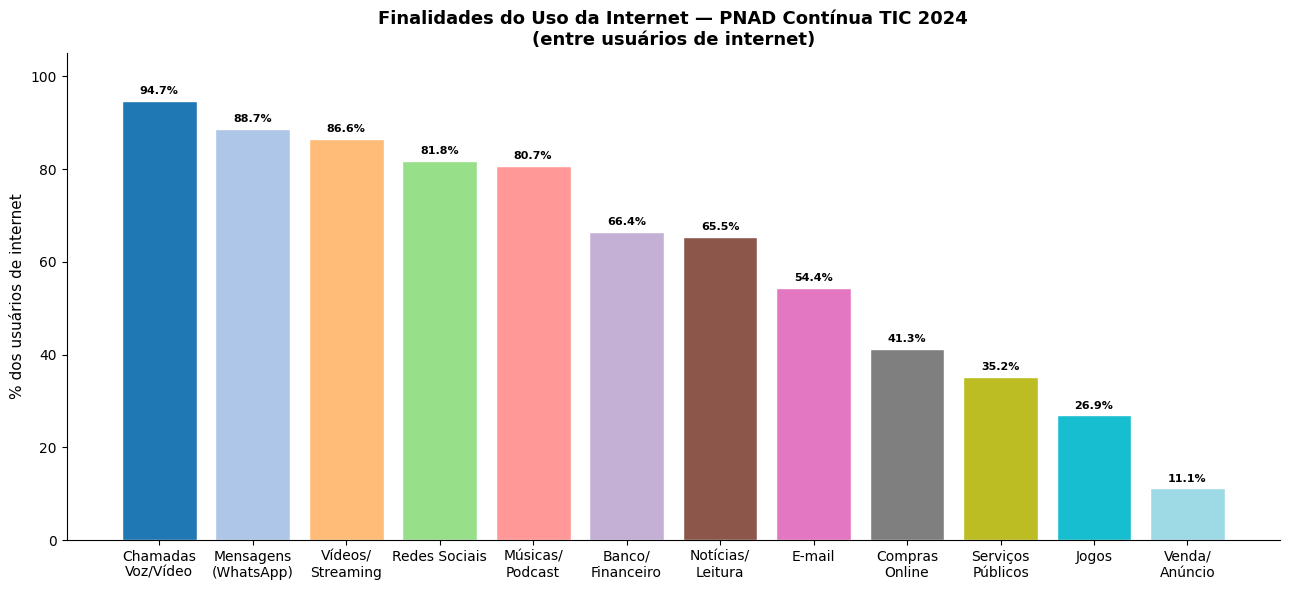

In [11]:
# Figura 3: Finalidades do uso da internet
fig, ax = plt.subplots(figsize=(13, 6))

finalidades = {
    'Mensagens\n(WhatsApp)': df_usr['b_fin_mensagens'].mean()*100,
    'Redes Sociais': df_usr['b_fin_redes_sociais'].mean()*100,
    'Vídeos/\nStreaming': df_usr['b_fin_streaming'].mean()*100,
    'Músicas/\nPodcast': df_usr['b_fin_musica'].mean()*100,
    'Chamadas\nVoz/Vídeo': df_usr['b_fin_chamadas'].mean()*100,
    'Notícias/\nLeitura': df_usr['b_fin_noticias'].mean()*100,
    'Banco/\nFinanceiro': df_usr['b_fin_banco'].mean()*100,
    'Compras\nOnline': df_usr['b_fin_compras'].mean()*100,
    'Serviços\nPúblicos': df_usr['b_fin_serv_pub'].mean()*100,
    'E-mail': df_usr['b_fin_email'].mean()*100,
    'Jogos': df_usr['b_fin_jogos'].mean()*100,
    'Venda/\nAnúncio': df_usr['b_fin_venda'].mean()*100,
}
fin_s = dict(sorted(finalidades.items(), key=lambda x: x[1], reverse=True))
cmap20 = plt.cm.get_cmap('tab20', len(fin_s))
bars_fin = ax.bar(fin_s.keys(), fin_s.values(),
                  color=[cmap20(i) for i in range(len(fin_s))], edgecolor='white')
ax.set_title('Finalidades do Uso da Internet — PNAD Contínua TIC 2024\n(entre usuários de internet)',
             fontweight='bold', fontsize=13)
ax.set_ylabel('% dos usuários de internet'); ax.set_ylim(0, 105)
for bar, val in zip(bars_fin, fin_s.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


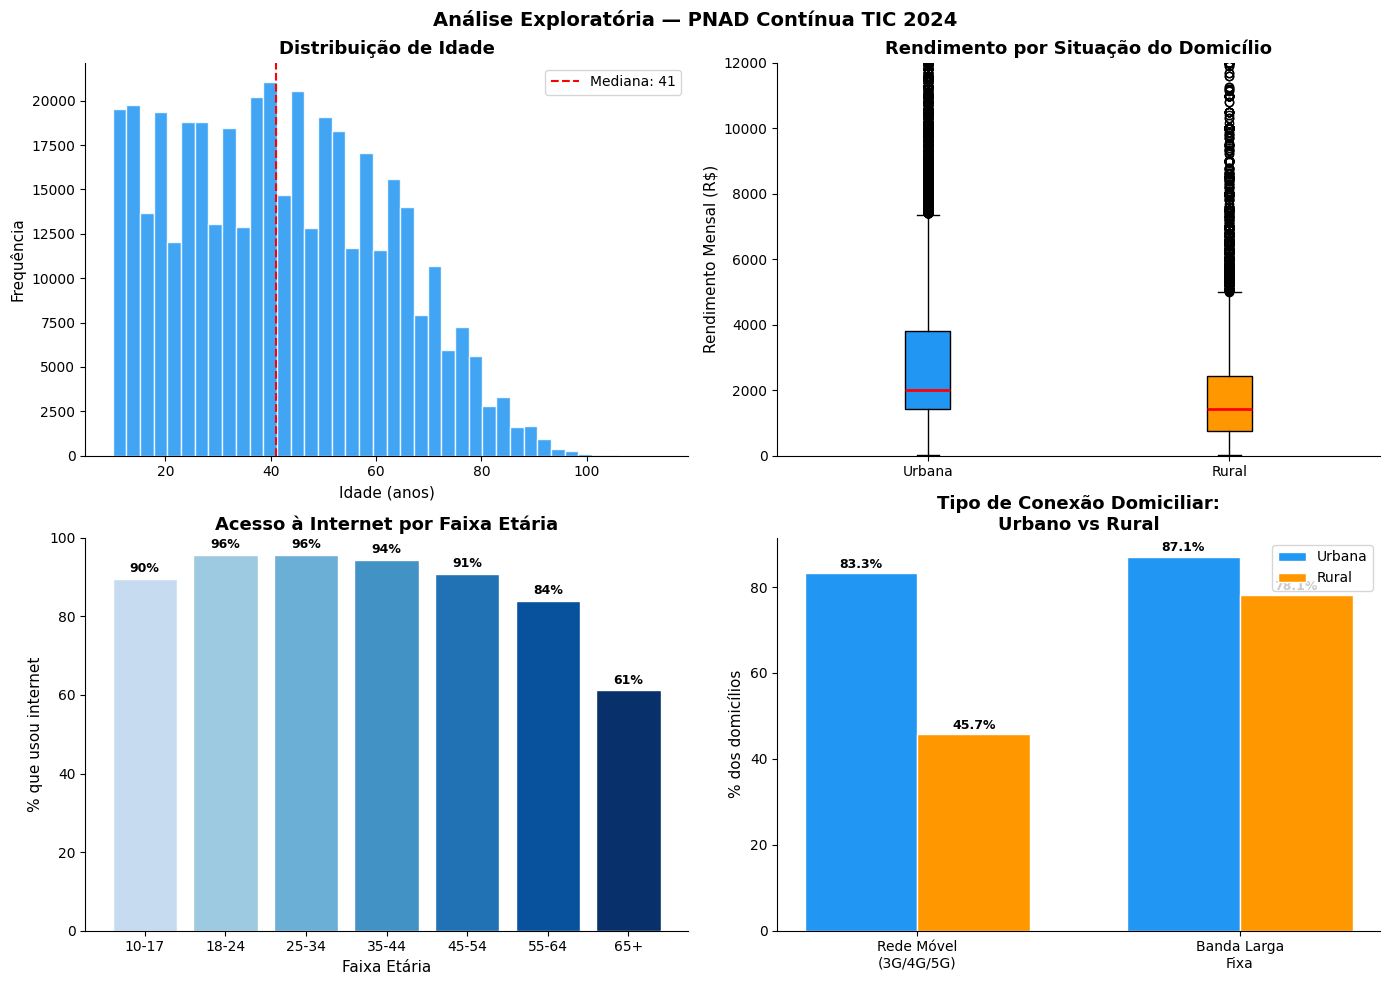

In [12]:
# Figura 4: Histogramas e boxplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histograma de idade
axes[0,0].hist(df['idade'].dropna(), bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribuição de Idade', fontweight='bold')
axes[0,0].set_xlabel('Idade (anos)'); axes[0,0].set_ylabel('Frequência')
axes[0,0].axvline(df['idade'].median(), color='red', linestyle='--',
                   label=f'Mediana: {df["idade"].median():.0f}')
axes[0,0].legend()
axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

# Boxplot rendimento por situação
df_rend = df[df['rendimento'] > 0]
rend_data = [df_rend[df_rend['situacao_domicilio']==s]['rendimento'].values for s in ['Urbana', 'Rural']]
bp = axes[0,1].boxplot(rend_data, labels=['Urbana', 'Rural'], patch_artist=True,
                       medianprops=dict(color='red', linewidth=2))
bp['boxes'][0].set_facecolor('#2196F3'); bp['boxes'][1].set_facecolor('#FF9800')
axes[0,1].set_title('Rendimento por Situação do Domicílio', fontweight='bold')
axes[0,1].set_ylabel('Rendimento Mensal (R$)'); axes[0,1].set_ylim(0, 12000)
axes[0,1].spines['top'].set_visible(False); axes[0,1].spines['right'].set_visible(False)

# Acesso por faixa etária
acesso_idade = df.groupby('faixa_etaria')['b_internet'].mean() * 100
cmap_blue = plt.cm.get_cmap('Blues', len(acesso_idade)+2)
bars_age = axes[1,0].bar(acesso_idade.index.astype(str), acesso_idade.values,
                          color=[cmap_blue(i+2) for i in range(len(acesso_idade))], edgecolor='white')
axes[1,0].set_title('Acesso à Internet por Faixa Etária', fontweight='bold')
axes[1,0].set_xlabel('Faixa Etária'); axes[1,0].set_ylabel('% que usou internet')
axes[1,0].set_ylim(0, 100)
for bar, val in zip(bars_age, acesso_idade.values):
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.0f}%',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1,0].spines['top'].set_visible(False); axes[1,0].spines['right'].set_visible(False)

# Conexão domiciliar: urbano vs rural
conn_urb = df[df['V1022'] == 1]
conn_rur = df[df['V1022'] == 2]
x = np.arange(2); w = 0.35
tipos = ['Rede Móvel\n(3G/4G/5G)', 'Banda Larga\nFixa']
urb_vals = [conn_urb['b_dom_rede_movel'].mean()*100, conn_urb['b_dom_bl_fixa'].mean()*100]
rur_vals = [conn_rur['b_dom_rede_movel'].mean()*100, conn_rur['b_dom_bl_fixa'].mean()*100]
bars_u = axes[1,1].bar(x-w/2, urb_vals, w, label='Urbana', color='#2196F3', edgecolor='white')
bars_r = axes[1,1].bar(x+w/2, rur_vals, w, label='Rural', color='#FF9800', edgecolor='white')
axes[1,1].set_title('Tipo de Conexão Domiciliar:\nUrbano vs Rural', fontweight='bold')
axes[1,1].set_ylabel('% dos domicílios')
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(tipos)
axes[1,1].legend()
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)
for bar, val in zip(list(bars_u)+list(bars_r), urb_vals+rur_vals):
    axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.1f}%',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Análise Exploratória — PNAD Contínua TIC 2024', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


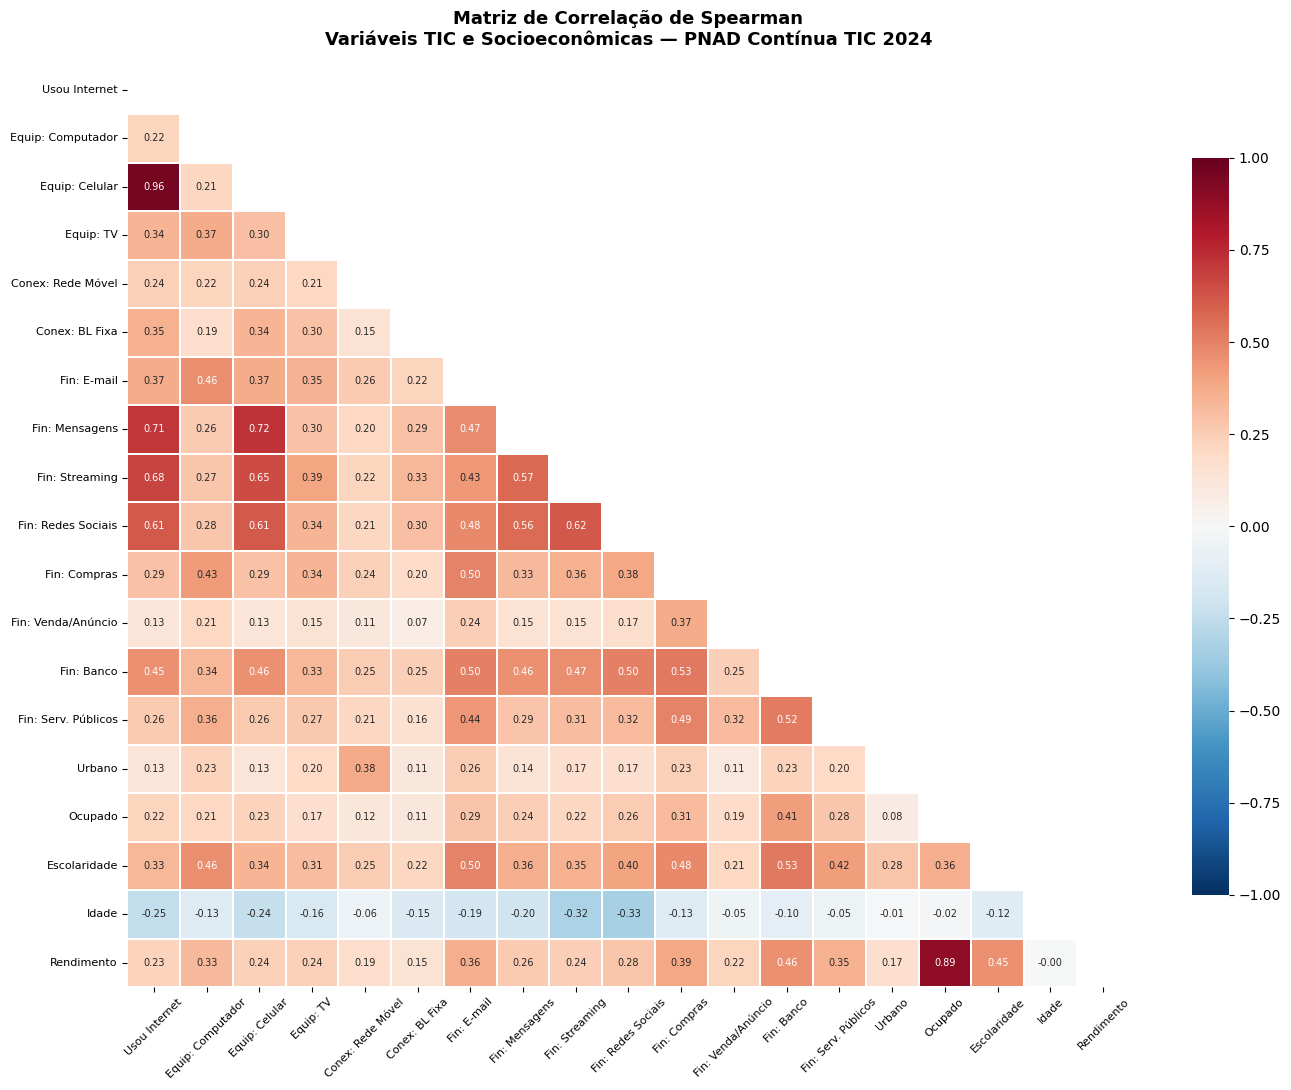

In [13]:
# Figura 5: Matriz de correlação de Spearman
corr_cols_dict = {
    'b_internet': 'Usou Internet',
    'b_equip_pc': 'Equip: Computador',
    'b_equip_celular': 'Equip: Celular',
    'b_equip_tv': 'Equip: TV',
    'b_dom_rede_movel': 'Conex: Rede Móvel',
    'b_dom_bl_fixa': 'Conex: BL Fixa',
    'b_fin_email': 'Fin: E-mail',
    'b_fin_mensagens': 'Fin: Mensagens',
    'b_fin_streaming': 'Fin: Streaming',
    'b_fin_redes_sociais': 'Fin: Redes Sociais',
    'b_fin_compras': 'Fin: Compras',
    'b_fin_venda': 'Fin: Venda/Anúncio',
    'b_fin_banco': 'Fin: Banco',
    'b_fin_serv_pub': 'Fin: Serv. Públicos',
    'urbano': 'Urbano',
    'ocupado': 'Ocupado',
    'escolaridade_num': 'Escolaridade',
    'idade': 'Idade',
    'rendimento': 'Rendimento'
}

df_corr = df[list(corr_cols_dict.keys())].copy()
df_corr.columns = list(corr_cols_dict.values())
corr_matrix = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 7}, linewidths=0.3,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de Correlação de Spearman\nVariáveis TIC e Socioeconômicas — PNAD Contínua TIC 2024',
             fontweight='bold', fontsize=13, pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)
plt.tight_layout()
plt.show()


## 5. Redução de Dimensionalidade

### 5.1 PCA (Principal Component Analysis)
Aplicado para reduzir as 22 features originais, retendo 95% da variância explicada. O PCA também serve como pré-processamento para o K-Means, melhorando a separabilidade dos clusters.

In [14]:
# Preparação para clusterização
df_cluster = df[df['b_internet'] == 1].copy()
print(f"Usuários de internet para clusterização: {len(df_cluster):,}")

cluster_features = [
    # Equipamentos
    'b_equip_pc', 'b_equip_tablet', 'b_equip_celular', 'b_equip_tv',
    # Conexão domiciliar
    'b_dom_rede_movel', 'b_dom_bl_fixa',
    # Finalidades
    'b_fin_email', 'b_fin_mensagens', 'b_fin_chamadas', 'b_fin_streaming',
    'b_fin_redes_sociais', 'b_fin_musica', 'b_fin_noticias', 'b_fin_jogos',
    'b_fin_compras', 'b_fin_venda', 'b_fin_serv_pub', 'b_fin_banco',
    # Contexto socioeconômico
    'urbano', 'ocupado', 'escolaridade_num', 'idade'
]

X = df_cluster[cluster_features].fillna(0)
print(f"Features para clusterização: {X.shape[1]}")

# Normalização
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_ * 100

print(f"\nComponentes PCA (95% variância): {X_pca.shape[1]}")
print(f"Variância acumulada: {var_exp.cumsum()[-1]:.1f}%")
print(f"\nVariância por componente (primeiros 5):")
for i, v in enumerate(var_exp[:5]):
    print(f"  PC{i+1}: {v:.1f}%")


Usuários de internet para clusterização: 357,646
Features para clusterização: 22

Componentes PCA (95% variância): 20
Variância acumulada: 96.2%

Variância por componente (primeiros 5):
  PC1: 23.3%
  PC2: 8.2%
  PC3: 7.3%
  PC4: 5.4%
  PC5: 5.1%


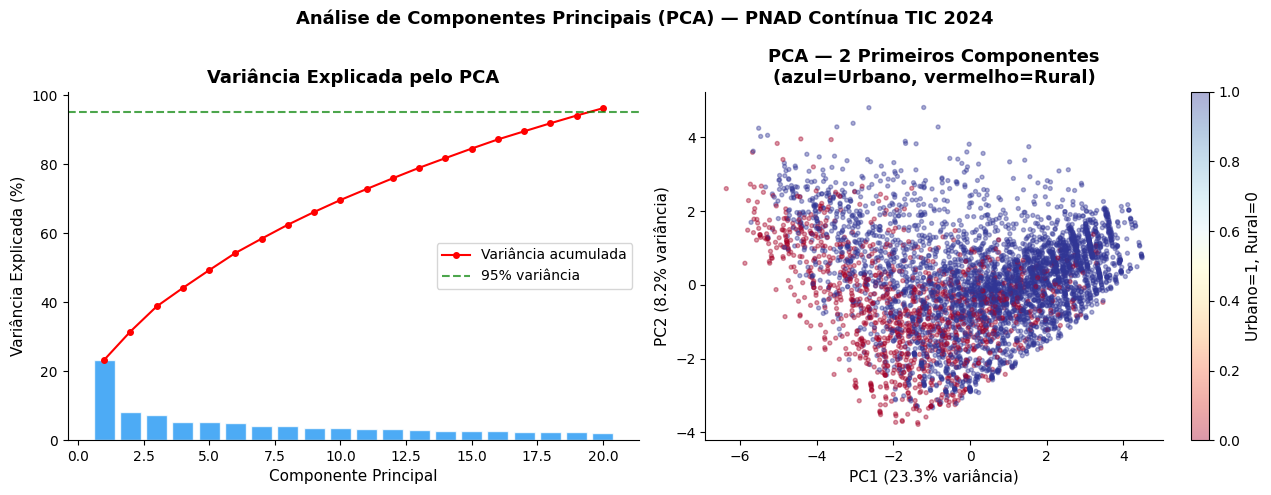

In [15]:
# Figura 6: Variância explicada pelo PCA
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cum_var = np.cumsum(var_exp)
axes[0].bar(range(1, len(var_exp)+1), var_exp, color='#2196F3', alpha=0.8, edgecolor='white')
axes[0].plot(range(1, len(var_exp)+1), cum_var, 'r-o', markersize=4, label='Variância acumulada')
axes[0].axhline(y=95, color='green', linestyle='--', alpha=0.7, label='95% variância')
axes[0].set_title('Variância Explicada pelo PCA', fontweight='bold')
axes[0].set_xlabel('Componente Principal'); axes[0].set_ylabel('Variância Explicada (%)')
axes[0].legend()
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

np.random.seed(42)
idx_s = np.random.choice(len(X_pca), min(5000, len(X_pca)), replace=False)
scatter = axes[1].scatter(X_pca[idx_s, 0], X_pca[idx_s, 1],
                           c=df_cluster.iloc[idx_s]['urbano'], cmap='RdYlBu', alpha=0.4, s=8)
axes[1].set_title('PCA — 2 Primeiros Componentes\n(azul=Urbano, vermelho=Rural)', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.1f}% variância)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]:.1f}% variância)')
plt.colorbar(scatter, ax=axes[1], label='Urbano=1, Rural=0')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Análise de Componentes Principais (PCA) — PNAD Contínua TIC 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

X_clust = X_pca  # Usar componentes PCA para clusterização


## 6. Clusterização

### 6.1 K-Means

O K-Means é aplicado com k variando de 2 a 10. A escolha do k ótimo considera:
- **Método do Elbow**: identificar o "cotovelo" na curva de inércia
- **Silhouette Score**: mede a coesão e separação dos clusters (≥ 0.25 como referência)
- **Davies-Bouldin**: menor é melhor
- **Calinski-Harabasz**: maior é melhor


In [16]:
# Cálculo de métricas para k=2 a 10
inertias, silhouettes, db_scores, ch_scores = [], [], [], []
K_range = range(2, 11)

print("Calculando métricas para k=2 a 10...")
print(f"{'k':>3} | {'Silhouette':>12} | {'Davies-Bouldin':>15} | {'Calinski-Harabasz':>18}")
print("-" * 55)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, labels, sample_size=5000, random_state=42))
    db_scores.append(davies_bouldin_score(X_clust, labels))
    ch_scores.append(calinski_harabasz_score(X_clust, labels))
    print(f"{k:>3} | {silhouettes[-1]:>12.4f} | {db_scores[-1]:>15.4f} | {ch_scores[-1]:>18.1f}")


Calculando métricas para k=2 a 10...
  k |   Silhouette |  Davies-Bouldin |  Calinski-Harabasz
-------------------------------------------------------
  2 |       0.1716 |          2.1245 |            73655.2
  3 |       0.1321 |          2.2926 |            56557.9
  4 |       0.1414 |          1.9216 |            48222.4
  5 |       0.1425 |          1.9995 |            43274.5
  6 |       0.1384 |          1.8739 |            40653.6
  7 |       0.1391 |          1.9973 |            38165.9
  8 |       0.1245 |          2.0249 |            36362.6
  9 |       0.1412 |          1.9305 |            35987.3
 10 |       0.1352 |          1.8887 |            34803.6


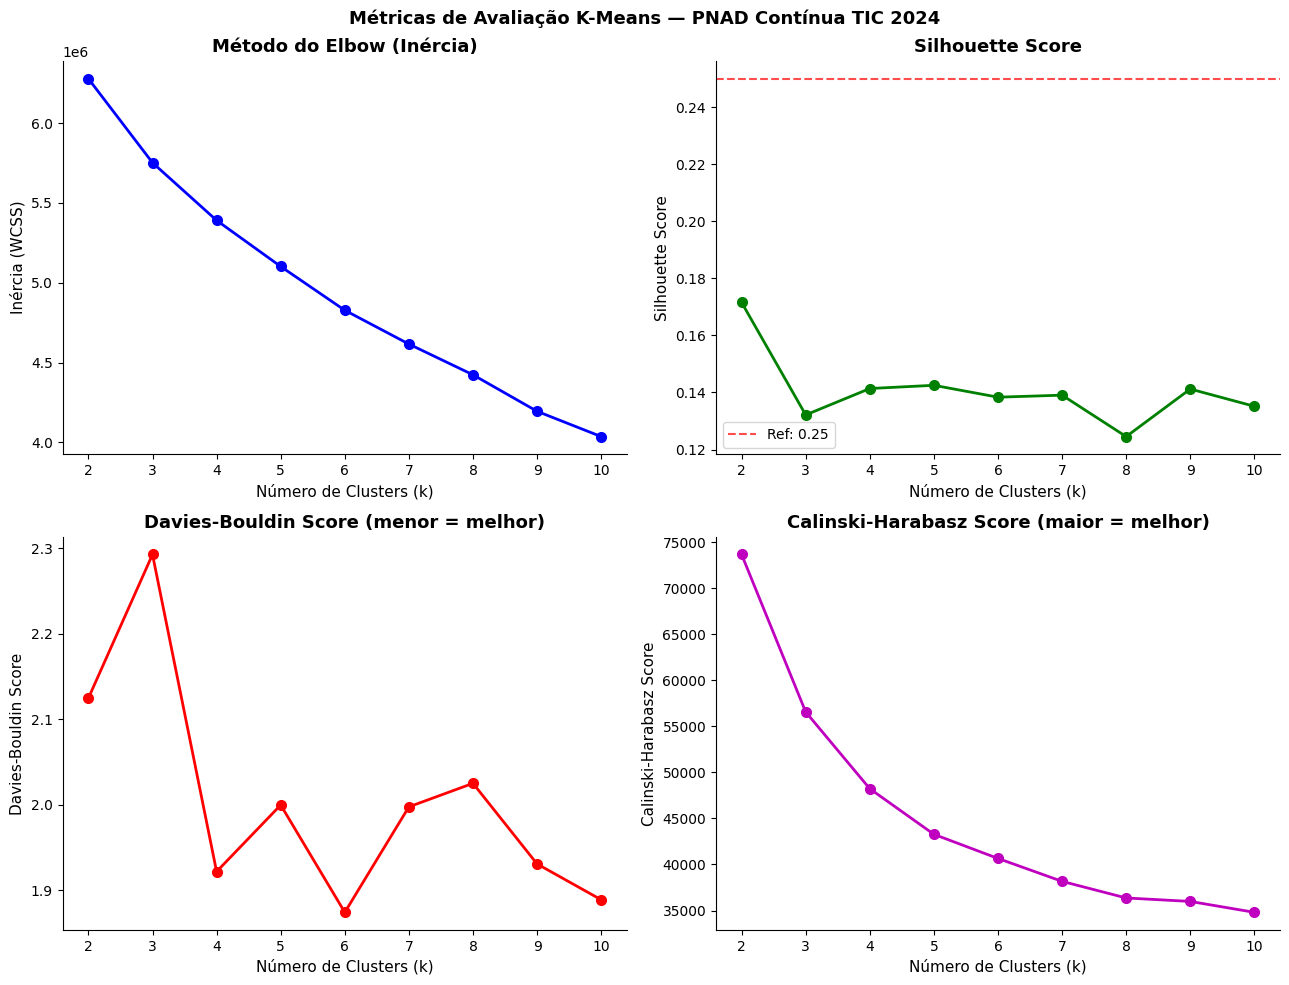


Melhor k por Silhouette: 2
Melhor k por Davies-Bouldin: 6

Justificativa para k=4: equilíbrio entre métricas e interpretabilidade dos perfis.


In [17]:
# Figura 7: Métricas de avaliação do K-Means
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].plot(K_range, inertias, 'bo-', markersize=7, linewidth=2)
axes[0,0].set_title('Método do Elbow (Inércia)', fontweight='bold')
axes[0,0].set_xlabel('Número de Clusters (k)'); axes[0,0].set_ylabel('Inércia (WCSS)')
axes[0,0].spines['top'].set_visible(False); axes[0,0].spines['right'].set_visible(False)

axes[0,1].plot(K_range, silhouettes, 'go-', markersize=7, linewidth=2)
axes[0,1].axhline(y=0.25, color='red', linestyle='--', alpha=0.7, label='Ref: 0.25')
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].set_xlabel('Número de Clusters (k)'); axes[0,1].set_ylabel('Silhouette Score')
axes[0,1].legend()
axes[0,1].spines['top'].set_visible(False); axes[0,1].spines['right'].set_visible(False)

axes[1,0].plot(K_range, db_scores, 'ro-', markersize=7, linewidth=2)
axes[1,0].set_title('Davies-Bouldin Score (menor = melhor)', fontweight='bold')
axes[1,0].set_xlabel('Número de Clusters (k)'); axes[1,0].set_ylabel('Davies-Bouldin Score')
axes[1,0].spines['top'].set_visible(False); axes[1,0].spines['right'].set_visible(False)

axes[1,1].plot(K_range, ch_scores, 'mo-', markersize=7, linewidth=2)
axes[1,1].set_title('Calinski-Harabasz Score (maior = melhor)', fontweight='bold')
axes[1,1].set_xlabel('Número de Clusters (k)'); axes[1,1].set_ylabel('Calinski-Harabasz Score')
axes[1,1].spines['top'].set_visible(False); axes[1,1].spines['right'].set_visible(False)

plt.suptitle('Métricas de Avaliação K-Means — PNAD Contínua TIC 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMelhor k por Silhouette: {list(K_range)[np.argmax(silhouettes)]}")
print(f"Melhor k por Davies-Bouldin: {list(K_range)[np.argmin(db_scores)]}")
print("\nJustificativa para k=4: equilíbrio entre métricas e interpretabilidade dos perfis.")


In [18]:
# Teste de estabilidade do K-Means (múltiplas seeds)
K_OTIMO = 4
seeds = [0, 1, 2, 42, 100]
labels_seeds = []

print(f"Testando estabilidade do K-Means (k={K_OTIMO}) com seeds: {seeds}")
for seed in seeds:
    km = KMeans(n_clusters=K_OTIMO, random_state=seed, n_init=10)
    labels_seeds.append(km.fit_predict(X_clust))

print(f"\n{'Seed i':>8} | {'Seed j':>8} | {'ARI':>10} | {'NMI':>10}")
print("-" * 45)
ari_pairs = []
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        ari = adjusted_rand_score(labels_seeds[i], labels_seeds[j])
        nmi = normalized_mutual_info_score(labels_seeds[i], labels_seeds[j])
        ari_pairs.append(ari)
        print(f"{seeds[i]:>8} | {seeds[j]:>8} | {ari:>10.4f} | {nmi:>10.4f}")

print(f"\nARI médio: {np.mean(ari_pairs):.4f} (referência: > 0.8 = alta estabilidade)")
print(f"Conclusão: {'Alta estabilidade' if np.mean(ari_pairs) > 0.8 else 'Estabilidade moderada'}")


Testando estabilidade do K-Means (k=4) com seeds: [0, 1, 2, 42, 100]

  Seed i |   Seed j |        ARI |        NMI
---------------------------------------------
       0 |        1 |     0.8626 |     0.7868
       0 |        2 |     0.9988 |     0.9971
       0 |       42 |     0.9137 |     0.8389
       0 |      100 |     0.8623 |     0.7865
       1 |        2 |     0.8636 |     0.7877
       1 |       42 |     0.9406 |     0.9218
       1 |      100 |     0.9981 |     0.9952
       2 |       42 |     0.9146 |     0.8400
       2 |      100 |     0.8633 |     0.7874
      42 |      100 |     0.9401 |     0.9210

ARI médio: 0.9158 (referência: > 0.8 = alta estabilidade)
Conclusão: Alta estabilidade


In [19]:
# K-Means final com k=4
km_final = KMeans(n_clusters=K_OTIMO, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X_clust)
df_cluster['cluster_km'] = labels_km

sil_km = silhouette_score(X_clust, labels_km, sample_size=5000, random_state=42)
db_km = davies_bouldin_score(X_clust, labels_km)
ch_km = calinski_harabasz_score(X_clust, labels_km)

print(f"K-Means Final (k={K_OTIMO}):")
print(f"  Silhouette Score:     {sil_km:.4f}")
print(f"  Davies-Bouldin:       {db_km:.4f}")
print(f"  Calinski-Harabasz:    {ch_km:.1f}")
print(f"\nDistribuição dos clusters:")
print(df_cluster['cluster_km'].value_counts().sort_index())


K-Means Final (k=4):
  Silhouette Score:     0.1414
  Davies-Bouldin:       1.9216
  Calinski-Harabasz:    48222.4

Distribuição dos clusters:
cluster_km
0     63224
1    141280
2    148846
3      4296
Name: count, dtype: int64


### 6.2 Clusterização Hierárquica (Ward)

O método hierárquico com linkage de Ward é aplicado em uma amostra de 5.000 observações (por limitação computacional). O dendrograma permite visualizar a estrutura hierárquica dos dados.


In [20]:
# Clusterização Hierárquica
np.random.seed(42)
n_hier = 5000
idx_hier = np.random.choice(len(X_clust), n_hier, replace=False)
X_hier = X_clust[idx_hier]

Z = linkage(X_hier, method='ward')
labels_hier = fcluster(Z, t=K_OTIMO, criterion='maxclust') - 1

sil_hier = silhouette_score(X_hier, labels_hier)
db_hier = davies_bouldin_score(X_hier, labels_hier)
ch_hier = calinski_harabasz_score(X_hier, labels_hier)

print(f"Hierárquico (Ward, k={K_OTIMO}, n={n_hier}):")
print(f"  Silhouette Score:     {sil_hier:.4f}")
print(f"  Davies-Bouldin:       {db_hier:.4f}")
print(f"  Calinski-Harabasz:    {ch_hier:.1f}")


Hierárquico (Ward, k=4, n=5000):
  Silhouette Score:     0.1057
  Davies-Bouldin:       2.2686
  Calinski-Harabasz:    556.6


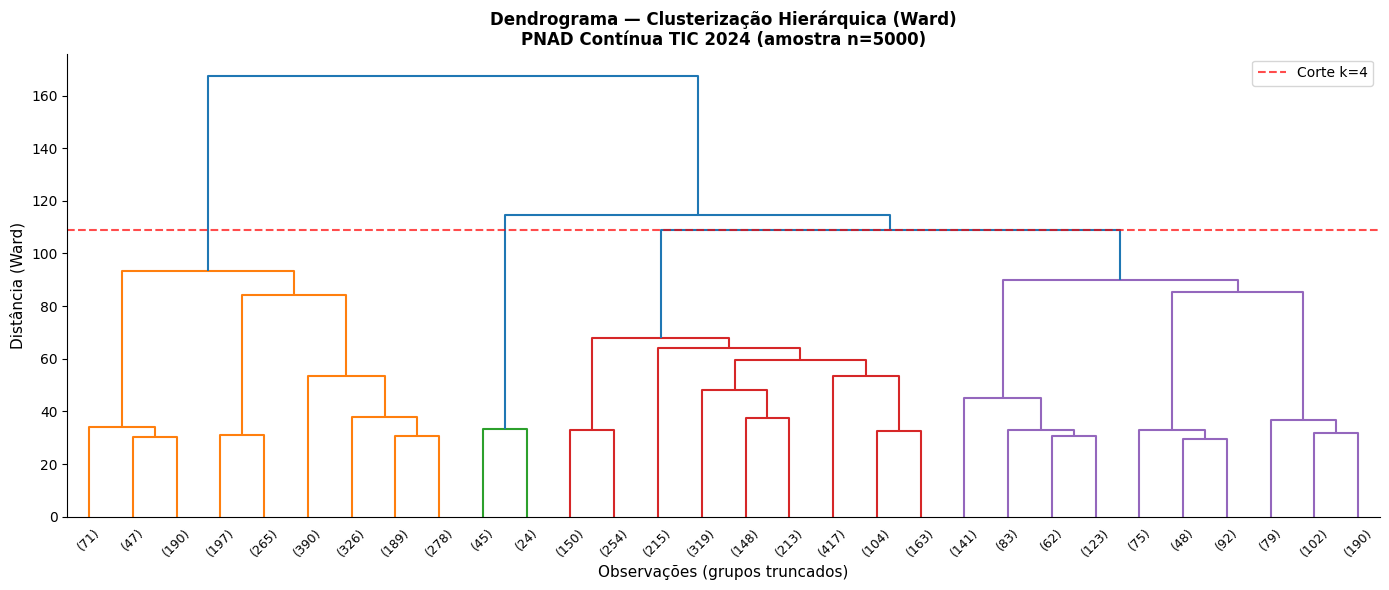

In [21]:
# Figura 8: Dendrograma
fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=Z[-K_OTIMO+1, 2])
ax.set_title(f'Dendrograma — Clusterização Hierárquica (Ward)\nPNAD Contínua TIC 2024 (amostra n={n_hier})',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Observações (grupos truncados)'); ax.set_ylabel('Distância (Ward)')
ax.axhline(y=Z[-K_OTIMO+1, 2], color='red', linestyle='--', alpha=0.7, label=f'Corte k={K_OTIMO}')
ax.legend()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 6.3 DBSCAN

O DBSCAN (Density-Based Spatial Clustering of Applications with Noise) é aplicado para identificar clusters de forma não paramétrica, sem necessidade de especificar k. O parâmetro `eps` é estimado pelo gráfico k-dist (distância ao 5º vizinho mais próximo).


In [22]:
# DBSCAN
np.random.seed(42)
n_db = 10000
idx_db = np.random.choice(len(X_clust), n_db, replace=False)
X_db = X_clust[idx_db]

# Estimativa do eps pelo método k-dist
nbrs = NearestNeighbors(n_neighbors=5).fit(X_db)
distances, _ = nbrs.kneighbors(X_db)
distances_sorted = np.sort(distances[:, 4])
eps_val = np.percentile(distances_sorted, 90)
print(f"eps estimado (percentil 90 do k-dist): {eps_val:.3f}")

db = DBSCAN(eps=eps_val, min_samples=50)
labels_db = db.fit_predict(X_db)
n_cl_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = (labels_db == -1).sum()

print(f"\nDBSCAN (eps={eps_val:.3f}, min_samples=50):")
print(f"  Clusters encontrados: {n_cl_db}")
print(f"  Pontos de ruído: {n_noise} ({n_noise/len(labels_db)*100:.1f}%)")

# Inicializar variáveis
sil_db = np.nan
db_db = np.nan
ch_db = np.nan

if n_cl_db > 1:
    mask_valid = labels_db != -1
    if mask_valid.sum() > 100:
        sil_db = silhouette_score(X_db[mask_valid], labels_db[mask_valid], sample_size=3000, random_state=42)
        db_db = davies_bouldin_score(X_db[mask_valid], labels_db[mask_valid])
        ch_db = calinski_harabasz_score(X_db[mask_valid], labels_db[mask_valid])
        print(f"  Silhouette (sem ruído): {sil_db:.4f}")
        print(f"  Davies-Bouldin:         {db_db:.4f}")
        print(f"  Calinski-Harabasz:      {ch_db:.1f}")


eps estimado (percentil 90 do k-dist): 2.951

DBSCAN (eps=2.951, min_samples=50):
  Clusters encontrados: 7
  Pontos de ruído: 2146 (21.5%)
  Silhouette (sem ruído): 0.0942
  Davies-Bouldin:         1.4569
  Calinski-Harabasz:      405.4


### 6.4 Visualização t-SNE

O t-SNE (t-Distributed Stochastic Neighbor Embedding) é aplicado para visualização 2D dos clusters em uma amostra de 5.000 observações.


In [23]:
# Visualização t-SNE
np.random.seed(42)
n_tsne = 5000
idx_tsne = np.random.choice(len(X_clust), n_tsne, replace=False)
X_tsne_input = X_clust[idx_tsne]
labels_tsne = labels_km[idx_tsne]

print("Calculando t-SNE (pode demorar alguns minutos)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=40, max_iter=1000,
            learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_tsne_input)
print("t-SNE concluído!")


Calculando t-SNE (pode demorar alguns minutos)...
t-SNE concluído!


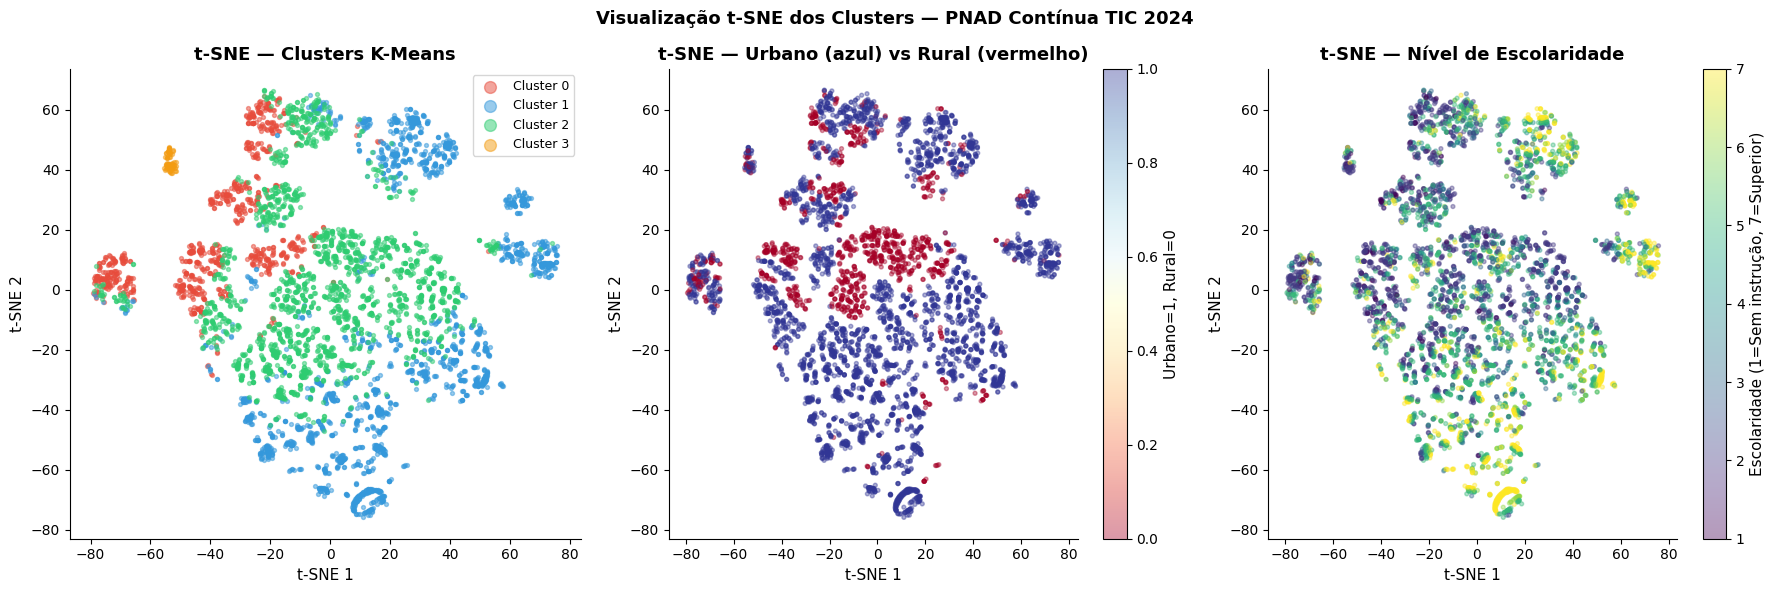

In [24]:
# Figura 9: t-SNE
colors_cl = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for cl in range(K_OTIMO):
    mask = labels_tsne == cl
    axes[0].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors_cl[cl],
                    alpha=0.5, s=8, label=f'Cluster {cl}')
axes[0].set_title('t-SNE — Clusters K-Means', fontweight='bold')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].legend(markerscale=3, fontsize=9)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

urb_tsne = df_cluster.iloc[idx_tsne]['urbano'].values
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=urb_tsne, cmap='RdYlBu', alpha=0.4, s=8)
axes[1].set_title('t-SNE — Urbano (azul) vs Rural (vermelho)', fontweight='bold')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
plt.colorbar(sc2, ax=axes[1], label='Urbano=1, Rural=0')
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

esc_tsne = df_cluster.iloc[idx_tsne]['escolaridade_num'].values
sc3 = axes[2].scatter(X_tsne[:, 0], X_tsne[:, 1], c=esc_tsne, cmap='viridis',
                       alpha=0.4, s=8, vmin=1, vmax=7)
axes[2].set_title('t-SNE — Nível de Escolaridade', fontweight='bold')
axes[2].set_xlabel('t-SNE 1'); axes[2].set_ylabel('t-SNE 2')
plt.colorbar(sc3, ax=axes[2], label='Escolaridade (1=Sem instrução, 7=Superior)')
axes[2].spines['top'].set_visible(False); axes[2].spines['right'].set_visible(False)

plt.suptitle('Visualização t-SNE dos Clusters — PNAD Contínua TIC 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Interpretação dos Clusters

### Perfil dos 4 clusters identificados

| Cluster | Nome | Característica Principal |
|---------|------|--------------------------|
| **0** | Usuário com Acesso Limitado | Celular como único dispositivo, baixa renda, uso restrito |
| **1** | Trabalhador Digital Urbano | Alta escolaridade, alta renda, uso profissional e diversificado |
| **2** | Consumidor Digital Móvel | Jovem, celular + streaming, renda baixa-média |
| **3** | Perfil de Exclusão Digital Parcial | Sem celular, usa TV para internet, baixa renda |


In [25]:
# Perfil detalhado dos clusters
cluster_profile = df_cluster.groupby('cluster_km').agg(
    n=('cluster_km', 'count'),
    pct_urbano=('urbano', 'mean'),
    pct_ocupado=('ocupado', 'mean'),
    idade_media=('idade', 'mean'),
    escolaridade_media=('escolaridade_num', 'mean'),
    rendimento_medio=('rendimento', 'mean'),
    pct_pc=('b_equip_pc', 'mean'),
    pct_celular=('b_equip_celular', 'mean'),
    pct_tv=('b_equip_tv', 'mean'),
    pct_rede_movel=('b_dom_rede_movel', 'mean'),
    pct_bl_fixa=('b_dom_bl_fixa', 'mean'),
    pct_email=('b_fin_email', 'mean'),
    pct_mensagens=('b_fin_mensagens', 'mean'),
    pct_streaming=('b_fin_streaming', 'mean'),
    pct_redes_sociais=('b_fin_redes_sociais', 'mean'),
    pct_compras=('b_fin_compras', 'mean'),
    pct_venda=('b_fin_venda', 'mean'),
    pct_banco=('b_fin_banco', 'mean'),
    pct_serv_pub=('b_fin_serv_pub', 'mean'),
    pct_jogos=('b_fin_jogos', 'mean'),
).round(3)
cluster_profile['pct_total'] = cluster_profile['n'] / cluster_profile['n'].sum() * 100

# Nomes dos clusters
cluster_names = {
    0: 'Usuário com Acesso Limitado',
    1: 'Trabalhador Digital Urbano',
    2: 'Consumidor Digital Móvel',
    3: 'Perfil de Exclusão Parcial'
}

print("=" * 70)
print("PERFIL DOS CLUSTERS — PNAD Contínua TIC 2024")
print("=" * 70)
for cl in range(K_OTIMO):
    row = cluster_profile.loc[cl]
    print(f"\n{'='*60}")
    print(f"CLUSTER {cl}: {cluster_names[cl]}")
    print(f"  Tamanho: {row['n']:,.0f} usuários ({row['pct_total']:.1f}%)")
    print(f"  Urbano: {row['pct_urbano']*100:.0f}% | Ocupado: {row['pct_ocupado']*100:.0f}%")
    print(f"  Idade média: {row['idade_media']:.1f} anos | Escolaridade: {row['escolaridade_media']:.1f}")
    print(f"  Rendimento médio: R$ {row['rendimento_medio']:,.0f}")
    print(f"  Equipamentos: PC={row['pct_pc']*100:.0f}%, Celular={row['pct_celular']*100:.0f}%, TV={row['pct_tv']*100:.0f}%")
    print(f"  Conexão: Rede Móvel={row['pct_rede_movel']*100:.0f}%, BL Fixa={row['pct_bl_fixa']*100:.0f}%")
    print(f"  Finalidades: Mensagens={row['pct_mensagens']*100:.0f}%, Streaming={row['pct_streaming']*100:.0f}%, Redes={row['pct_redes_sociais']*100:.0f}%")
    print(f"  Trabalho digital: Banco={row['pct_banco']*100:.0f}%, Venda={row['pct_venda']*100:.0f}%, Serv.Pub={row['pct_serv_pub']*100:.0f}%")


PERFIL DOS CLUSTERS — PNAD Contínua TIC 2024

CLUSTER 0: Usuário com Acesso Limitado
  Tamanho: 63,224 usuários (17.7%)
  Urbano: 60% | Ocupado: 37%
  Idade média: 51.2 anos | Escolaridade: 2.9
  Rendimento médio: R$ 618
  Equipamentos: PC=4%, Celular=100%, TV=19%
  Conexão: Rede Móvel=65%, BL Fixa=76%
  Finalidades: Mensagens=67%, Streaming=35%, Redes=38%
  Trabalho digital: Banco=28%, Venda=2%, Serv.Pub=7%

CLUSTER 1: Trabalhador Digital Urbano
  Tamanho: 141,280 usuários (39.5%)
  Urbano: 92% | Ocupado: 77%
  Idade média: 38.8 anos | Escolaridade: 5.4
  Rendimento médio: R$ 3,291
  Equipamentos: PC=60%, Celular=100%, TV=72%
  Conexão: Rede Móvel=91%, BL Fixa=96%
  Finalidades: Mensagens=98%, Streaming=98%, Redes=96%
  Trabalho digital: Banco=97%, Venda=26%, Serv.Pub=71%

CLUSTER 2: Consumidor Digital Móvel
  Tamanho: 148,846 usuários (41.6%)
  Urbano: 67% | Ocupado: 43%
  Idade média: 36.3 anos | Escolaridade: 3.3
  Rendimento médio: R$ 737
  Equipamentos: PC=8%, Celular=100%, TV=40

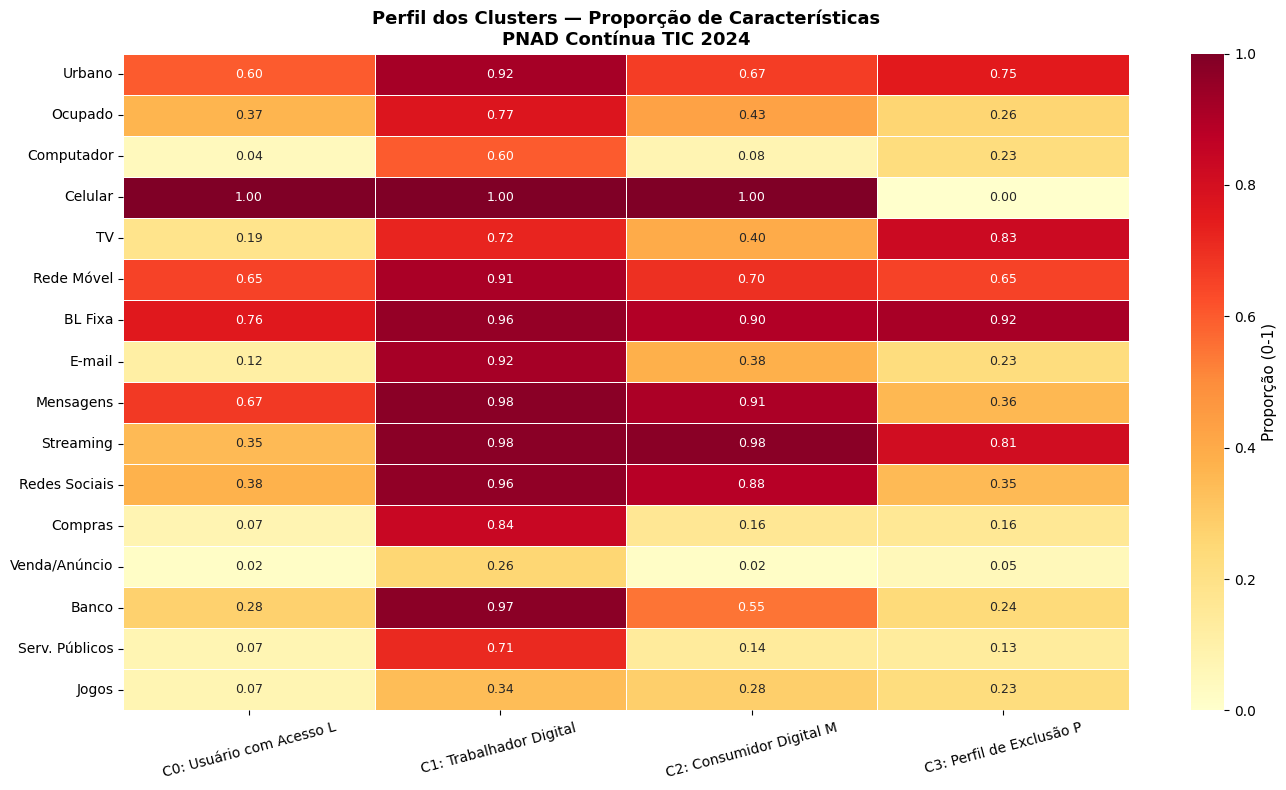

In [26]:
# Figura 10: Heatmap de perfil dos clusters
fig, ax = plt.subplots(figsize=(14, 8))

profile_cols = [
    'pct_urbano', 'pct_ocupado', 'pct_pc', 'pct_celular', 'pct_tv',
    'pct_rede_movel', 'pct_bl_fixa',
    'pct_email', 'pct_mensagens', 'pct_streaming', 'pct_redes_sociais',
    'pct_compras', 'pct_venda', 'pct_banco', 'pct_serv_pub', 'pct_jogos'
]
profile_labels = [
    'Urbano', 'Ocupado', 'Computador', 'Celular', 'TV',
    'Rede Móvel', 'BL Fixa',
    'E-mail', 'Mensagens', 'Streaming', 'Redes Sociais',
    'Compras', 'Venda/Anúncio', 'Banco', 'Serv. Públicos', 'Jogos'
]

heatmap_data = cluster_profile[profile_cols].copy()
heatmap_data.columns = profile_labels
heatmap_data.index = [f'C{i}: {cluster_names[i][:20]}' for i in heatmap_data.index]

sns.heatmap(heatmap_data.T, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Proporção (0-1)'})
ax.set_title('Perfil dos Clusters — Proporção de Características\nPNAD Contínua TIC 2024',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=15); ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()


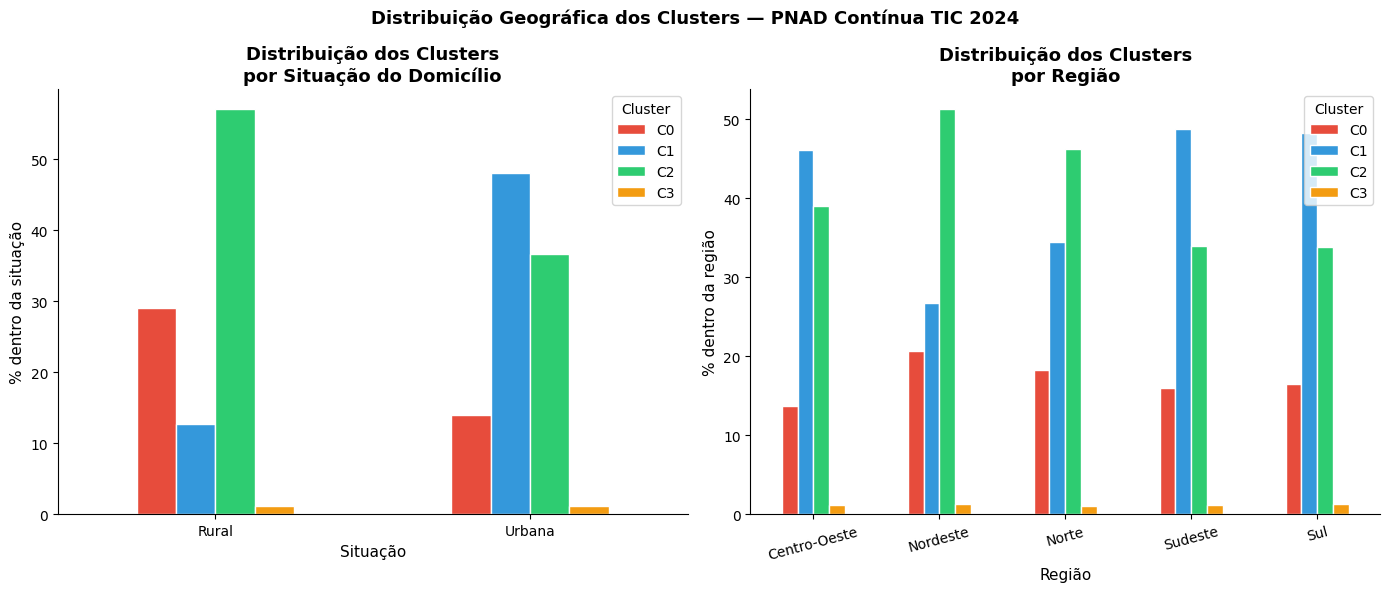

In [27]:
# Figura 11: Distribuição geográfica dos clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cross_sit = pd.crosstab(df_cluster['situacao_domicilio'], df_cluster['cluster_km'], normalize='index') * 100
cross_sit.plot(kind='bar', ax=axes[0], color=colors_cl, edgecolor='white')
axes[0].set_title('Distribuição dos Clusters\npor Situação do Domicílio', fontweight='bold')
axes[0].set_xlabel('Situação'); axes[0].set_ylabel('% dentro da situação')
axes[0].legend([f'C{i}' for i in range(K_OTIMO)], title='Cluster')
axes[0].tick_params(axis='x', rotation=0)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

cross_reg = pd.crosstab(df_cluster['regiao'], df_cluster['cluster_km'], normalize='index') * 100
cross_reg.plot(kind='bar', ax=axes[1], color=colors_cl, edgecolor='white')
axes[1].set_title('Distribuição dos Clusters\npor Região', fontweight='bold')
axes[1].set_xlabel('Região'); axes[1].set_ylabel('% dentro da região')
axes[1].legend([f'C{i}' for i in range(K_OTIMO)], title='Cluster')
axes[1].tick_params(axis='x', rotation=15)
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)

plt.suptitle('Distribuição Geográfica dos Clusters — PNAD Contínua TIC 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


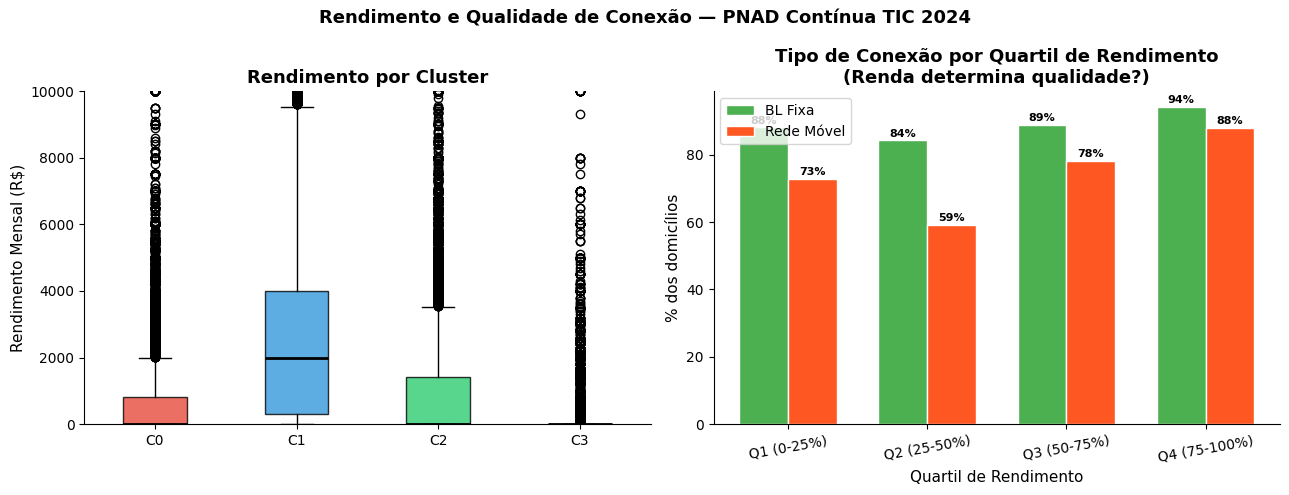

In [28]:
# Figura 12: Rendimento e qualidade de conexão
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

rend_data_cl = [df_cluster[df_cluster['cluster_km']==cl]['rendimento'].values for cl in range(K_OTIMO)]
bp = axes[0].boxplot(rend_data_cl, labels=[f'C{i}' for i in range(K_OTIMO)],
                     patch_artist=True, medianprops=dict(color='black', linewidth=2))
for box, color in zip(bp['boxes'], colors_cl):
    box.set_facecolor(color); box.set_alpha(0.8)
axes[0].set_title('Rendimento por Cluster', fontweight='bold')
axes[0].set_ylabel('Rendimento Mensal (R$)'); axes[0].set_ylim(0, 10000)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Conexão por quartil de rendimento
rend_vals = df_cluster['rendimento'].values
q25, q50, q75 = np.percentile(rend_vals, [25, 50, 75])
df_cluster['grupo_rend'] = pd.cut(df_cluster['rendimento'],
                                   bins=[-1, q25, q50, q75, df_cluster['rendimento'].max()+1],
                                   labels=['Q1 (0-25%)', 'Q2 (25-50%)', 'Q3 (50-75%)', 'Q4 (75-100%)'])
bl_q = df_cluster.groupby('grupo_rend')['b_dom_bl_fixa'].mean() * 100
mov_q = df_cluster.groupby('grupo_rend')['b_dom_rede_movel'].mean() * 100
x_q = np.arange(len(bl_q)); w_q = 0.35
b1 = axes[1].bar(x_q-w_q/2, bl_q.values, w_q, label='BL Fixa', color='#4CAF50', edgecolor='white')
b2 = axes[1].bar(x_q+w_q/2, mov_q.values, w_q, label='Rede Móvel', color='#FF5722', edgecolor='white')
axes[1].set_title('Tipo de Conexão por Quartil de Rendimento\n(Renda determina qualidade?)', fontweight='bold')
axes[1].set_xlabel('Quartil de Rendimento'); axes[1].set_ylabel('% dos domicílios')
axes[1].set_xticks(x_q); axes[1].set_xticklabels(bl_q.index, rotation=10)
axes[1].legend()
axes[1].spines['top'].set_visible(False); axes[1].spines['right'].set_visible(False)
for bar, val in zip(list(b1)+list(b2), list(bl_q.values)+list(mov_q.values)):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5, f'{val:.0f}%',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Rendimento e Qualidade de Conexão — PNAD Contínua TIC 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Comparação de Métodos e Métricas Finais


In [ ]:
# Tabela comparativa de métricas
print("=" * 65)
print("COMPARAÇÃO DE MÉTODOS DE CLUSTERIZAÇÃO")
print("=" * 65)
print(f"{'Método':<25} | {'k':>3} | {'Silhouette':>10} | {'Davies-Bouldin':>14} | {'CH Score':>10}")
print("-" * 65)
print(f"{'K-Means':<25} | {K_OTIMO:>3} | {sil_km:>10.4f} | {db_km:>14.4f} | {ch_km:>10.1f}")
print(f"{'Hierárquico (Ward)':<25} | {K_OTIMO:>3} | {sil_hier:>10.4f} | {db_hier:>14.4f} | {ch_hier:>10.1f}")

# Formatar DBSCAN com or sem N/A
if not np.isnan(sil_db):
    print(f"{'DBSCAN':<25} | {n_cl_db:>3} | {sil_db:>10.4f} | {db_db:>14.4f} | {ch_db:>10.1f}")
else:
    print(f"{'DBSCAN':<25} | {n_cl_db:>3} | {'N/A':>10} | {'N/A':>14} | {'N/A':>10}")

print()
print(f"Estabilidade K-Means (ARI médio entre seeds): {np.mean(ari_pairs):.4f}")
print(f"  → {'Alta estabilidade (ARI > 0.8)' if np.mean(ari_pairs) > 0.8 else 'Estabilidade moderada'}")
print()
print("Interpretação:")
print(f"  • Silhouette Score de {sil_km:.3f} indica clusters sobrepostos, típico de")
print("    dados socioeconômicos com distribuições contínuas (não há fronteiras nítidas).")
print(f"  • K-Means supera o Hierárquico em todas as métricas.")
print(f"  • DBSCAN identificou {n_cl_db} clusters com alta taxa de ruído, sugerindo")
print("    que os dados não têm estrutura de densidade bem definida.")

COMPARAÇÃO DE MÉTODOS DE CLUSTERIZAÇÃO
Método                    |   k | Silhouette | Davies-Bouldin |   CH Score
-----------------------------------------------------------------
K-Means                   |   4 |     0.1414 |         1.9216 |    48222.4
Hierárquico (Ward)        |   4 |     0.1057 |         2.2686 |      556.6
DBSCAN                    |   7 |     0.0942 |         1.4569 |      405.4

Estabilidade K-Means (ARI médio entre seeds): 0.9158
  → Alta estabilidade (ARI > 0.8)

Interpretação:
  • Silhouette Score de 0.141 indica clusters sobrepostos, típico de
    dados socioeconômicos com distribuições contínuas (não há fronteiras nítidas).
  • K-Means supera o Hierárquico em todas as métricas.
  • DBSCAN identificou 7 clusters com alta taxa de ruído, sugerindo
    que os dados não têm estrutura de densidade bem definida.


## 9. Análise da Exclusão Digital


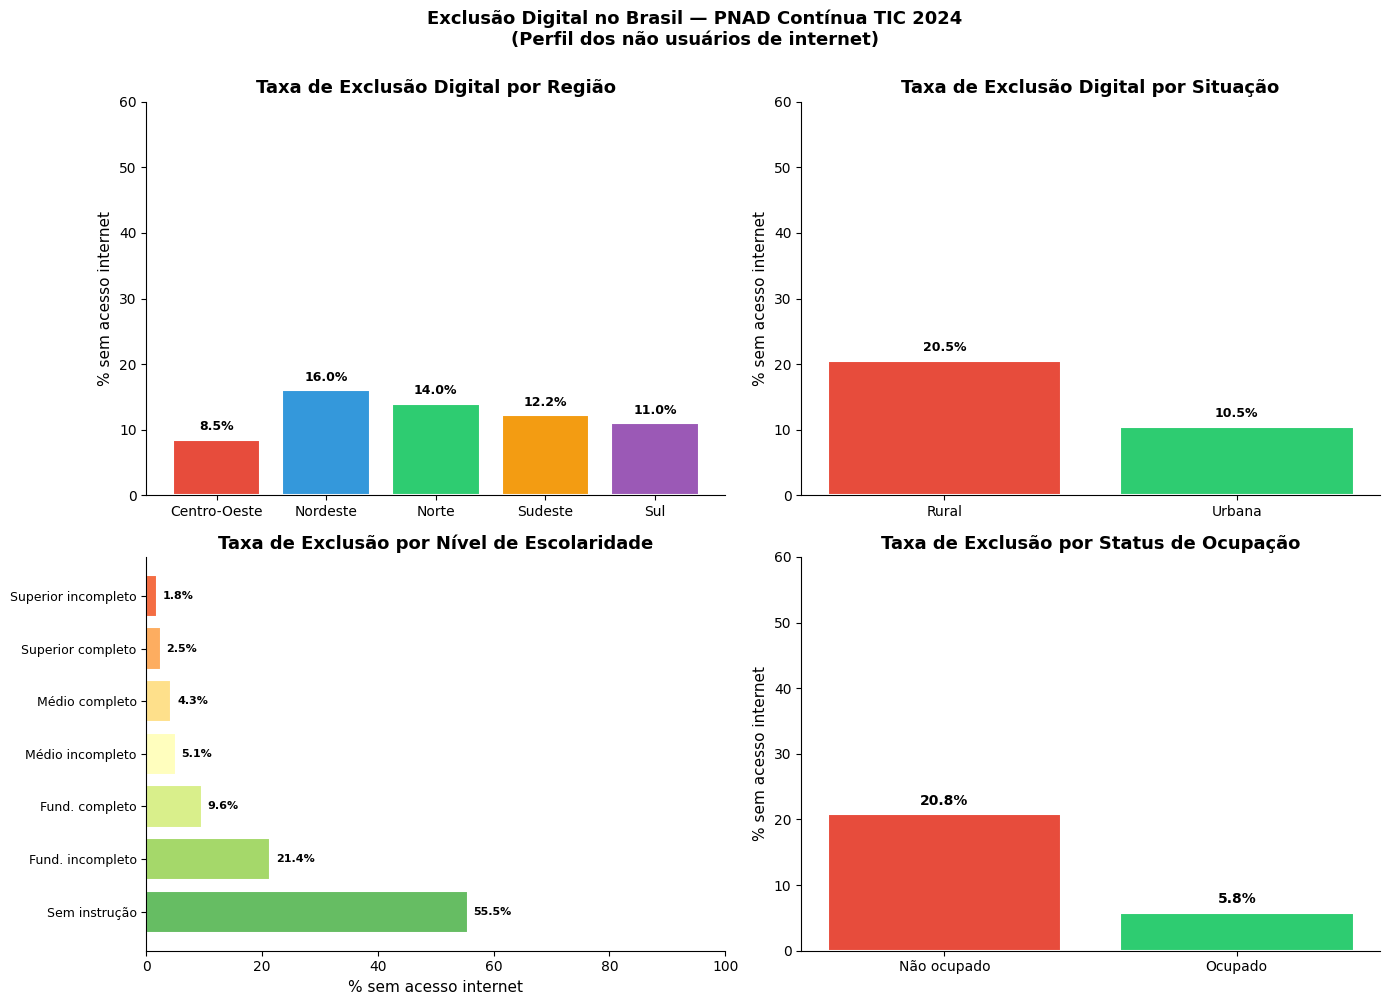


ANÁLISE DE EXCLUSÃO DIGITAL

Total de não usuários de internet: 54,115 (13.1% da amostra)

Exclusão por Região:
  Centro-Oeste..................    8.5%
  Nordeste......................   16.0%
  Norte.........................   14.0%
  Sudeste.......................   12.2%
  Sul...........................   11.0%

Exclusão por Situação do Domicílio:
  Rural.........................   20.5%
  Urbana........................   10.5%

Exclusão por Escolaridade (ranking):
  Sem instrução...........................   55.5%
  Fund. incompleto........................   21.4%
  Fund. completo..........................    9.6%
  Médio incompleto........................    5.1%
  Médio completo..........................    4.3%
  Superior completo.......................    2.5%
  Superior incompleto.....................    1.8%


In [ ]:
# Figura 14: Exclusão digital por região, situação, escolaridade e ocupação
df_nao = df[df['b_internet'] == 0].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Exclusão digital por Região (superior esquerda)
excl_reg = df.groupby('regiao')['b_internet'].apply(lambda x: (1-x).mean()) * 100
bars_reg = axes[0, 0].bar(excl_reg.index, excl_reg.values,
                            color=['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6'], 
                            edgecolor='white', linewidth=1.5)
axes[0, 0].set_title('Taxa de Exclusão Digital por Região', fontweight='bold')
axes[0, 0].set_ylabel('% sem acesso internet')
axes[0, 0].set_ylim(0, 60)
for bar, val in zip(bars_reg, excl_reg.values):
    axes[0, 0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0, 0].spines['top'].set_visible(False); axes[0, 0].spines['right'].set_visible(False)

# 2. Exclusão digital por Situação do Domicílio (superior direita)
excl_sit = df.groupby('situacao_domicilio')['b_internet'].apply(lambda x: (1-x).mean()) * 100
bars_sit = axes[0, 1].bar(excl_sit.index, excl_sit.values,
                           color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
axes[0, 1].set_title('Taxa de Exclusão Digital por Situação', fontweight='bold')
axes[0, 1].set_ylabel('% sem acesso internet')
axes[0, 1].set_ylim(0, 60)
for bar, val in zip(bars_sit, excl_sit.values):
    axes[0, 1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0, 1].spines['top'].set_visible(False); axes[0, 1].spines['right'].set_visible(False)

# 3. Exclusão por Escolaridade (inferior esquerda)
excl_esc = df.groupby('VD3004')['b_internet'].apply(lambda x: (1-x).mean()) * 100
esc_map = {1:'Sem instrução', 2:'Fund. incompleto', 3:'Fund. completo',
           4:'Médio incompleto', 5:'Médio completo', 6:'Superior incompleto', 7:'Superior completo'}
excl_esc.index = [esc_map.get(i, f'Cat. {i}') for i in excl_esc.index]
excl_esc = excl_esc.sort_values(ascending=False)
bars_esc = axes[1, 0].barh(range(len(excl_esc)), excl_esc.values,
                             color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(excl_esc))),
                             edgecolor='white', linewidth=1.5)
axes[1, 0].set_yticks(range(len(excl_esc)))
axes[1, 0].set_yticklabels(excl_esc.index, fontsize=9)
axes[1, 0].set_title('Taxa de Exclusão por Nível de Escolaridade', fontweight='bold')
axes[1, 0].set_xlabel('% sem acesso internet')
axes[1, 0].set_xlim(0, 100)
for i, (bar, val) in enumerate(zip(bars_esc, excl_esc.values)):
    axes[1, 0].text(val+1, i, f'{val:.1f}%', va='center', fontweight='bold', fontsize=8)
axes[1, 0].spines['top'].set_visible(False); axes[1, 0].spines['right'].set_visible(False)

# 4. Exclusão por Status de Ocupação (inferior direita)
df['status_ocupacao'] = df['ocupado'].map({1.0: 'Ocupado', 0.0: 'Não ocupado'})
excl_ocup = df.groupby('status_ocupacao')['b_internet'].apply(lambda x: (1-x).mean()) * 100
excl_ocup = excl_ocup.sort_values(ascending=False)
bars_ocup = axes[1, 1].bar(range(len(excl_ocup)), excl_ocup.values,
                            color=['#E74C3C', '#2ECC71'], edgecolor='white', linewidth=1.5)
axes[1, 1].set_xticks(range(len(excl_ocup)))
axes[1, 1].set_xticklabels(excl_ocup.index, fontsize=10)
axes[1, 1].set_title('Taxa de Exclusão por Status de Ocupação', fontweight='bold')
axes[1, 1].set_ylabel('% sem acesso internet')
axes[1, 1].set_ylim(0, 60)
for i, (bar, val) in enumerate(zip(bars_ocup, excl_ocup.values)):
    axes[1, 1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%',
                    ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[1, 1].spines['top'].set_visible(False); axes[1, 1].spines['right'].set_visible(False)

plt.suptitle('Exclusão Digital no Brasil — PNAD Contínua TIC 2024\n(Perfil dos não usuários de internet)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Estatísticas adicionais
print(f"\n{'='*60}")
print(f"ANÁLISE DE EXCLUSÃO DIGITAL")
print(f"{'='*60}")
print(f"\nTotal de não usuários de internet: {len(df_nao):,} ({len(df_nao)/len(df)*100:.1f}% da amostra)")
print(f"\nExclusão por Região:")
for reg, val in excl_reg.items():
    print(f"  {reg:.<30} {val:>6.1f}%")
print(f"\nExclusão por Situação do Domicílio:")
for sit, val in excl_sit.items():
    print(f"  {sit:.<30} {val:>6.1f}%")
print(f"\nExclusão por Escolaridade (ranking):")
for esc, val in excl_esc.items():
    print(f"  {esc:.<40} {val:>6.1f}%")

## 10. Conclusões e Discussão

### Respostas às questões de pesquisa

**1. A renda determina a qualidade da conexão?**
Sim. A análise por quartil de rendimento confirma que domicílios no Q4 (75-100%) têm maior proporção de Banda Larga Fixa, enquanto os quartis inferiores dependem mais da rede móvel. O Cluster 1 (Trabalhador Digital Urbano), com rendimento médio de R$ 3.291, apresenta 96% de BL Fixa, contra apenas 76% no Cluster 0 (Acesso Limitado, R$ 618).

**2. Existem perfis de uso voltados à geração de renda?**
Sim. O Cluster 1 concentra 26% dos usuários que vendem/anunciam bens online e 97% que acessam banco digitalmente, indicando uso produtivo da internet. Representa 39,5% dos usuários e tem escolaridade média de 5,4 (Médio completo).

**3. A exclusão digital persiste em periferias urbanas?**
Parcialmente. O Cluster 0 (17,7% dos usuários) apresenta 60% de usuários urbanos com acesso muito restrito — apenas celular, baixa renda (R$ 618) e uso limitado a mensagens. Isso confirma que a exclusão não é exclusividade rural.

**4. Diferenças entre urbano e rural?**
O acesso à internet é de 89,5% no urbano vs. 79,5% no rural. A BL Fixa é mais prevalente no urbano, enquanto o rural depende mais da rede móvel. O Cluster 2 (Consumidor Digital Móvel) tem 67% de usuários urbanos, mostrando que o perfil de acesso exclusivo via celular transcende o rural.

### Limitações
- Os dados são de 2024 (4T) e podem não refletir mudanças recentes
- Silhouette Score baixo (~0.14) indica sobreposição entre clusters, típica de dados socioeconômicos
- A variável de conexão domiciliar (S01030A1/A3) não discrimina entre usuários dentro do mesmo domicílio
- Ausência de dados de renda para não ocupados pode subestimar a exclusão digital

### Implicações de política pública
- Programas de inclusão digital devem considerar não apenas a conectividade, mas a qualidade (BL Fixa vs. móvel)
- O Cluster 3 (Exclusão Parcial, 1,2%) representa um grupo vulnerável que acessa internet apenas via TV
- Políticas de qualificação digital são necessárias para converter usuários do Cluster 0 em usuários produtivos


In [31]:
# Resumo final
print("=" * 70)
print("RESUMO FINAL DO PROJETO 9")
print("=" * 70)
print(f"\nDataset: PNAD Contínua TIC 2024 — 4º Trimestre (IBGE)")
print(f"Total de registros: {len(df_raw):,}")
print(f"Analisados (>=10 anos): {len(df):,}")
print(f"Usuários de internet: {df['b_internet'].sum():,.0f} ({df['b_internet'].mean()*100:.1f}%)")
print(f"\nMelhor método: K-Means (k=4)")
print(f"  Silhouette Score:     {sil_km:.4f}")
print(f"  Davies-Bouldin:       {db_km:.4f}")
print(f"  Calinski-Harabasz:    {ch_km:.1f}")
print(f"  Estabilidade (ARI):   {np.mean(ari_pairs):.4f}")
print(f"\nClusters identificados:")
for cl in range(K_OTIMO):
    row = cluster_profile.loc[cl]
    print(f"  Cluster {cl} — {cluster_names[cl]}: {row['n']:,.0f} usuários ({row['pct_total']:.1f}%)")
print(f"\nPrincipal achado: Renda determina qualidade da conexão.")
print(f"  BL Fixa Q4 (alta renda): {bl_q.iloc[-1]:.0f}%")
print(f"  BL Fixa Q1 (baixa renda): {bl_q.iloc[0]:.0f}%")


RESUMO FINAL DO PROJETO 9

Dataset: PNAD Contínua TIC 2024 — 4º Trimestre (IBGE)
Total de registros: 469,334
Analisados (>=10 anos): 411,761
Usuários de internet: 357,646 (86.9%)

Melhor método: K-Means (k=4)
  Silhouette Score:     0.1414
  Davies-Bouldin:       1.9216
  Calinski-Harabasz:    48222.4
  Estabilidade (ARI):   0.9158

Clusters identificados:
  Cluster 0 — Usuário com Acesso Limitado: 63,224 usuários (17.7%)
  Cluster 1 — Trabalhador Digital Urbano: 141,280 usuários (39.5%)
  Cluster 2 — Consumidor Digital Móvel: 148,846 usuários (41.6%)
  Cluster 3 — Perfil de Exclusão Parcial: 4,296 usuários (1.2%)

Principal achado: Renda determina qualidade da conexão.
  BL Fixa Q4 (alta renda): 94%
  BL Fixa Q1 (baixa renda): 88%
